# 🔬 Automated Skin Lesion & Dermatological Disease Classification
### *Deep Learning-Driven Computer Vision Pipeline for Clinical Diagnostic Assistance*

---

[![Python](https://img.shields.io/badge/Python-3.10%2B-blue.svg?logo=python&logoColor=white)](#)
[![Framework](https://img.shields.io/badge/Framework-TensorFlow%20%7C%20PyTorch-orange.svg)](#)
[![Domain](https://img.shields.io/badge/Domain-Healthcare%20AI%20%2F%20Computer%20Vision-emerald.svg)](#)
[![Task](https://img.shields.io/badge/Task-Multi--Class%20Image%20Classification-purple.svg)](#)
[![Status](https://img.shields.io/badge/Status-Active%20Development-green.svg)](#)

---

## 📌 Executive Summary
Early and accurate detection of dermatological pathologies is critical for reducing diagnostic latency, triaging high-risk cases, and improving patient outcomes. This project delivers an end-to-end, production-grade Deep Learning pipeline designed to classify dermatological images across multiple diagnostic categories.

By leveraging state-of-the-art Convolutional Neural Network (CNN) and Transformer backbones alongside robust preprocessing and imbalance-handling strategies, this system serves as an objective, scalable decision-support framework for clinical workflows.

---

## 🎯 Core Project Objectives

* **High-Accuracy Triage & Classification:** Accurately identify and categorize skin lesions from dermoscopic and clinical imagery.
* **Class Imbalance Mitigation:** Implement advanced data augmentation, class weighting, and specialized loss functions (e.g., Focal Loss) to address real-world medical data skew.
* **Interpretability & Model Explainability:** Utilize visual attribution techniques (e.g., Grad-CAM) to ensure predictions are clinically interpretable and grounded in lesion morphology.
* **Edge & Production Optimization:** Prepare lightweight, quantized model artifacts (e.g., TFLite / ONNX) suitable for on-premise, web, or mobile deployment.

---

## 🏗️ End-to-End Pipeline Architecture

| Stage | Phase | Focus Area | Key Methodologies |
| :--- | :--- | :--- | :--- |
| **01** | **Ingestion & EDA** | Data Quality | Class distribution analysis, resolution standardization, artifact removal |
| **02** | **Preprocessing** | Augmentation | Color jittering, geometric transformations, normalization (ImageNet stats) |
| **03** | **Modeling** | Transfer Learning | Modern CNN / Transformer backbones (e.g., EfficientNet, MobileNet, ResNet) |
| **04** | **Optimization** | Fine-Tuning | Layer-wise unfreezing, Cosine Annealing, AdamW, Focal Loss |
| **05** | **Evaluation** | Diagnostics | Macro F1-Score, Balanced Accuracy, Per-Class Sensitivity, Confusion Matrix |
| **06** | **Deployment** | Inference Engine | Metric export, model serialization, quantization (FP16 / INT8) |

---

## 📊 Key Performance Indicators (KPIs)
To evaluate clinical efficacy, model performance is assessed against:
* **Balanced Accuracy & Macro F1-Score:** Ensuring minority pathological classes receive equal diagnostic weight.
* **High-Risk Sensitivity / Recall (e.g., Melanoma):** Minimizing false-negative rates on critical conditions.
* **Area Under the ROC Curve (AUC-ROC):** Assessing discrimination capability across varying confidence thresholds.

---

## 📋 Project Metadata

* **Author / Lead Engineer:** `[Bahri Ahmed Oualid]`
* **Dataset:** `[https://www.kaggle.com/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images]`
* **Target Classes:** `[ Melanoma, Melanocytic Nevus, Basal Cell Carcinoma, Actinic Keratosis]`
* **Base Architecture:** `[EfficientNet-B2 / MobileNetV2 / ResNet18]`
* **Target Deployment:** `[Mobile (TFLite) / Web API (FastAPI) / Embedded]`

---

> ⚠️ **Clinical & Ethical Disclaimer:**  
> *This notebook and associated models are intended for research, benchmarking, and clinical decision-support prototyping. They do not constitute certified medical devices and must not be used as a standalone replacement for professional dermatological examination.*

In [1]:
# ==============================================================================
# 01. CORE SYSTEM & ENVIRONMENT IMPORTS
# ==============================================================================
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import sys
import gc
import time
import math
import random
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional

import numpy as np
import pandas as pd
from PIL import Image
import cv2

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import class_weight
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, f1_score, recall_score, precision_score,
    roc_auc_score, roc_curve, auc
)

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False


import keras
from keras import layers, models, optimizers, callbacks, regularizers
import tensorflow as tf
os.environ["KERAS_BACKEND"] = "tensorflow"
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
tf.config.set_visible_devices([], 'GPU')
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

def set_global_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    tf.random.set_seed(seed)

def setup_compute_device() -> str:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            device_info = f"GPU Active ({len(gpus)} device(s): {gpus[0].name})"
        except RuntimeError as e:
            device_info = f"GPU Configuration Error: {e}"
    else:
        device_info = "CPU Active (No GPU Detected)"
    return device_info

DIAGNOSIS_DICT: Dict[str, str] = {
    'nv': 'Melanocytic Nevi (Benign Mole)',
    'mel': 'Melanoma (Malignant Skin Cancer)',
    'bkl': 'Benign Keratosis-like Lesions',
    'bcc': 'Basal Cell Carcinoma (Malignant)',
    'akiec': 'Actinic Keratoses / Intraepithelial Carcinoma',
    'vasc': 'Vascular Lesions (Angiomas / Hemorrhages)',
    'df': 'Dermatofibroma (Benign)'
}

MALIGNANCY_RISK: Dict[str, str] = {
    'nv': 'Benign', 'mel': 'Malignant (Critical)', 'bkl': 'Benign',
    'bcc': 'Malignant', 'akiec': 'Pre-cancerous / In-situ',
    'vasc': 'Benign', 'df': 'Benign'
}

# ------------------------------------------------------------------
# KAGGLE-SPECIFIC PATHS: input is read-only, working is where you save
# ------------------------------------------------------------------
CONFIG: Dict[str, Any] = {
    "PROJECT_NAME": "HAM10000-Multimodal-Skin-Lesion-Classification",
    "SEED": 42,

    "ARTIFACTS_DIR": Path("/kaggle/working/artifacts"),
    "CHECKPOINT_DIR": Path("/kaggle/working/artifacts/checkpoints"),
    "MODELS_DIR": Path("/kaggle/working/artifacts/models"),
    "PLOTS_DIR": Path("/kaggle/working/artifacts/plots"),

    "IMAGE_SIZE": (224, 224),
    "IMAGE_CHANNELS": 3,
    "BATCH_SIZE": 16,
    "NUM_CLASSES": 7,
    "TARGET_COL": "dx",
    "METADATA_NUMERIC_COLS": ["age"],
    "METADATA_CATEGORICAL_COLS": ["sex", "localization"],

    "TRAIN_RATIO": 0.70,
    "VAL_RATIO": 0.15,
    "TEST_RATIO": 0.15,

    "CNN_BACKBONE": "EfficientNetB0",
    "INITIAL_LR": 1e-3,
    "AUTOTUNE": tf.data.AUTOTUNE
}

set_global_seed(CONFIG["SEED"])
hardware_status = setup_compute_device()

for folder in ["ARTIFACTS_DIR", "CHECKPOINT_DIR", "MODELS_DIR", "PLOTS_DIR"]:
    CONFIG[folder].mkdir(parents=True, exist_ok=True)

print("=" * 75)
print(f"🚀 MULTIMODAL SKIN CLASSIFICATION PIPELINE INITIALIZED")
print("=" * 75)
print(f" • Execution Device    : {hardware_status}")
print(f" • Python Version      : {sys.version.split()[0]}")
print(f" • TensorFlow Version  : {tf.__version__}")
print(f" • Keras Version       : {keras.__version__}")
print(f" • Target Classes (7)  : {', '.join(DIAGNOSIS_DICT.keys())}")
print(f" • Artifacts Path      : {CONFIG['ARTIFACTS_DIR'].resolve()}")
print("=" * 75)

🚀 MULTIMODAL SKIN CLASSIFICATION PIPELINE INITIALIZED
 • Execution Device    : GPU Active (2 device(s): /physical_device:GPU:0)
 • Python Version      : 3.12.13
 • TensorFlow Version  : 2.20.0
 • Keras Version       : 3.13.2
 • Target Classes (7)  : nv, mel, bkl, bcc, akiec, vasc, df
 • Artifacts Path      : /kaggle/working/artifacts


 • Image folders scanned : 2
 • Total images found    : 10015

 • Shape    : (10015, 7)
 • Columns  : ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

 • Rows with missing image file : 0 / 10015

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


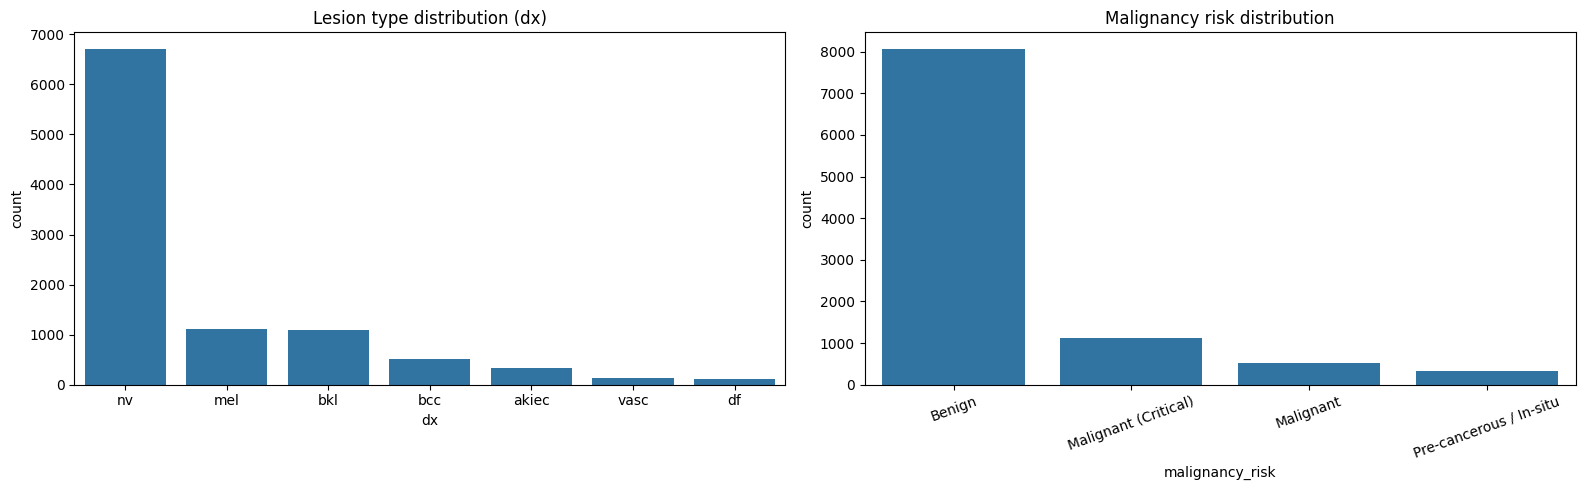

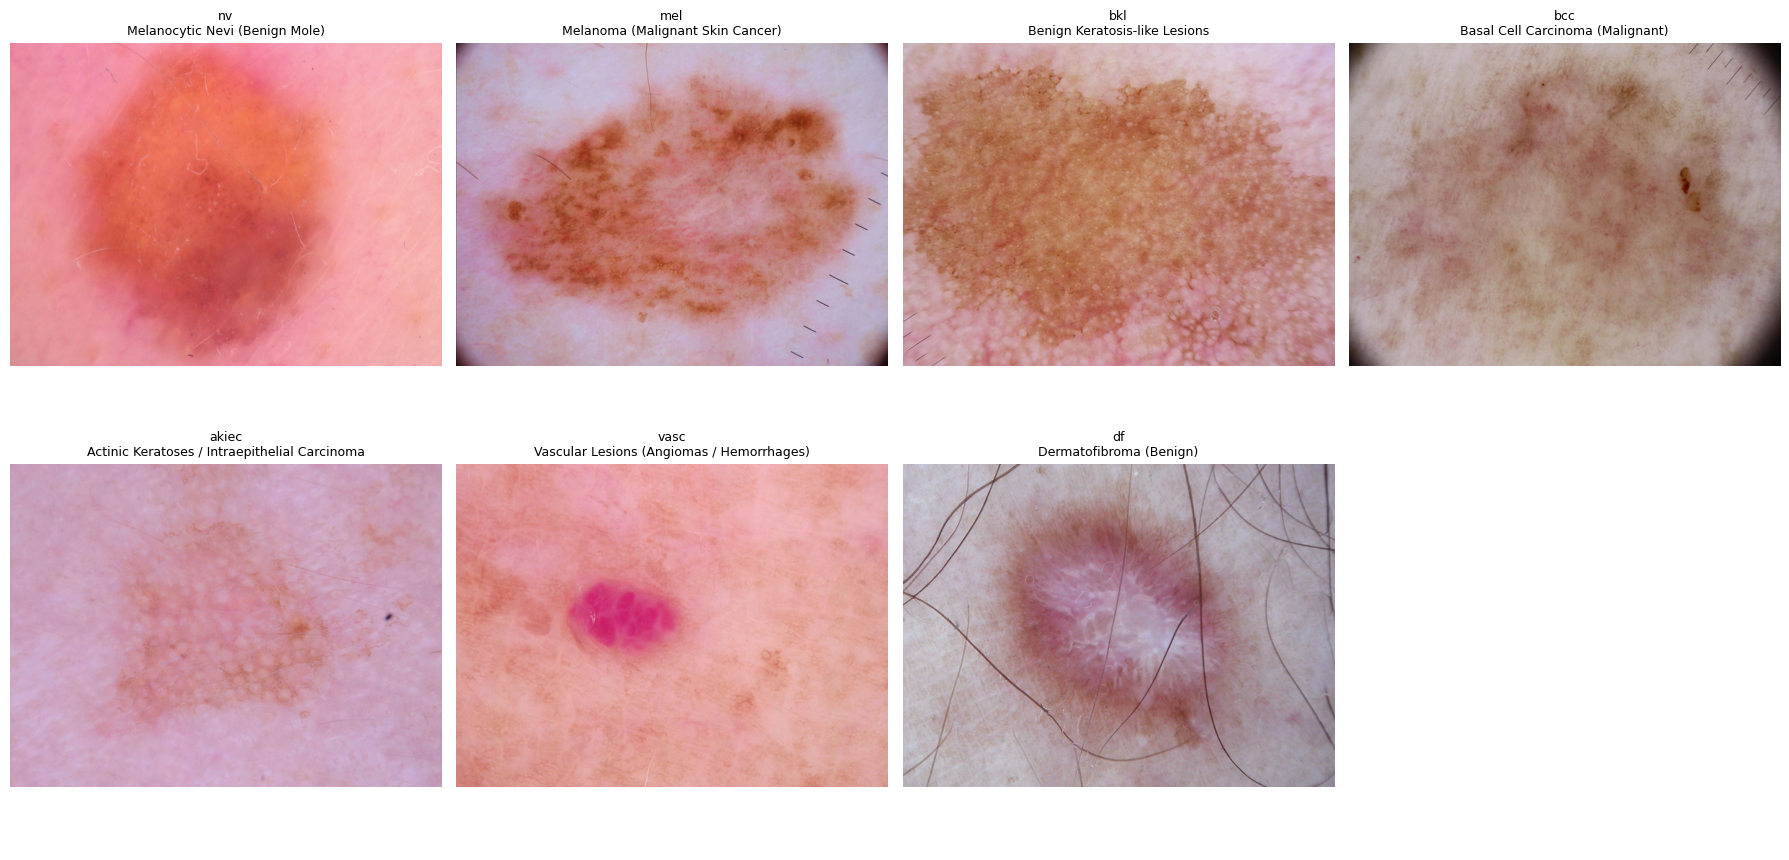


✅ PHASE 1 COMPLETE — cleaned metadata saved to: /kaggle/working/artifacts/ham10000_cleaned_metadata.csv
 • Final shape: (10015, 11)


In [2]:
# ==============================================================================
# 07. DATA PATHS — Kaggle mounts the dataset read-only under /kaggle/input/
# ==============================================================================
DATASET_ROOT = Path("/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000")

METADATA_CSV_PATH = DATASET_ROOT / "HAM10000_metadata.csv"
IMAGES_DIR = [
    DATASET_ROOT / "HAM10000_images_part_1",
    DATASET_ROOT / "HAM10000_images_part_2",
]

# ==============================================================================
# 08. BUILD AN IMAGE LOOKUP (image_id -> full file path)
# ==============================================================================
image_lookup = {}
for d in IMAGES_DIR:
    if not d.exists():
        print(f" ⚠ Folder not found, skipping: {d}")
        continue
    for img_path in d.glob("*.jpg"):
        image_lookup[img_path.stem] = img_path

print(f" • Image folders scanned : {len(IMAGES_DIR)}")
print(f" • Total images found    : {len(image_lookup)}")

# ==============================================================================
# 09. LOAD METADATA
# ==============================================================================
metadata = pd.read_csv(METADATA_CSV_PATH)
print(f"\n • Shape    : {metadata.shape}")
print(f" • Columns  : {list(metadata.columns)}")
metadata.head()

# ==============================================================================
# 10. ATTACH IMAGE PATHS + VALIDATE
# ==============================================================================
metadata["image_path"] = metadata["image_id"].map(image_lookup)
metadata["image_exists"] = metadata["image_path"].notnull()

missing_images = (~metadata["image_exists"]).sum()
print(f"\n • Rows with missing image file : {missing_images} / {len(metadata)}")

if missing_images > 0:
    metadata = metadata[metadata["image_exists"]].reset_index(drop=True)

assert len(metadata) > 0, "No images matched — check DATASET_ROOT path."

# ==============================================================================
# 11. ENRICH + CLEAN
# ==============================================================================
metadata["dx_full_name"] = metadata[CONFIG["TARGET_COL"]].map(DIAGNOSIS_DICT)
metadata["malignancy_risk"] = metadata[CONFIG["TARGET_COL"]].map(MALIGNANCY_RISK)
metadata["age"] = metadata["age"].fillna(metadata["age"].median())
metadata = metadata.dropna(subset=CONFIG["METADATA_CATEGORICAL_COLS"]).reset_index(drop=True)

# ==============================================================================
# 12. CLASS DISTRIBUTION
# ==============================================================================
class_counts = metadata[CONFIG["TARGET_COL"]].value_counts()
print("\nClass distribution:")
print(class_counts)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(data=metadata, x=CONFIG["TARGET_COL"], order=class_counts.index, ax=axes[0])
axes[0].set_title("Lesion type distribution (dx)")
sns.countplot(data=metadata, x="malignancy_risk",
              order=metadata["malignancy_risk"].value_counts().index, ax=axes[1])
axes[1].set_title("Malignancy risk distribution")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(CONFIG["PLOTS_DIR"] / "class_distribution.png", dpi=150)
plt.show()

# ==============================================================================
# 13. SAMPLE IMAGES PER CLASS
# ==============================================================================
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, dx_code in zip(axes.flatten(), DIAGNOSIS_DICT.keys()):
    subset = metadata[metadata[CONFIG["TARGET_COL"]] == dx_code]
    if len(subset) == 0:
        ax.axis("off")
        continue
    sample_row = subset.sample(1, random_state=CONFIG["SEED"]).iloc[0]
    img = Image.open(sample_row["image_path"])
    ax.imshow(img)
    ax.set_title(f"{dx_code}\n{DIAGNOSIS_DICT[dx_code]}", fontsize=9)
    ax.axis("off")
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.savefig(CONFIG["PLOTS_DIR"] / "sample_images_per_class.png", dpi=150)
plt.show()

# ==============================================================================
# 14. SAVE CLEANED METADATA
# ==============================================================================
cleaned_path = CONFIG["ARTIFACTS_DIR"] / "ham10000_cleaned_metadata.csv"
metadata.to_csv(cleaned_path, index=False)
print(f"\n✅ PHASE 1 COMPLETE — cleaned metadata saved to: {cleaned_path}")
print(f" • Final shape: {metadata.shape}")

In [3]:
import os
print(os.listdir("/kaggle/input"))

['datasets', 'notebooks']


In [4]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root, "->", len(files), "files")

/kaggle/input -> 0 files
/kaggle/input/datasets -> 0 files
/kaggle/input/datasets/kmader -> 0 files
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000 -> 5 files
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1 -> 5000 files
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/ham10000_images_part_1 -> 5000 files
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2 -> 5015 files
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/ham10000_images_part_2 -> 5015 files
/kaggle/input/notebooks -> 0 files
/kaggle/input/notebooks/raniaioan -> 0 files
/kaggle/input/notebooks/raniaioan/starter-skin-cancer-mnist-ham10000-6a5a3b01-0 -> 5 files
/kaggle/input/notebooks/raniaioan/starter-skin-cancer-mnist-ham10000-6a5a3b01-0/__results___files -> 7 files


 • Loaded cleaned metadata : (10015, 11)
 • Columns                 : ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'image_path', 'image_exists', 'dx_full_name', 'malignancy_risk']

Label mapping (code -> encoded number):
  akiec  ->  0   (Actinic Keratoses / Intraepithelial Carcinoma)
  bcc  ->  1   (Basal Cell Carcinoma (Malignant))
  bkl  ->  2   (Benign Keratosis-like Lesions)
  df  ->  3   (Dermatofibroma (Benign))
  mel  ->  4   (Melanoma (Malignant Skin Cancer))
  nv  ->  5   (Melanocytic Nevi (Benign Mole))
  vasc  ->  6   (Vascular Lesions (Angiomas / Hemorrhages))

 • Features used : ['age', 'sex', 'localization']
 • X shape        : (10015, 3)
 • y shape        : (10015,)

 • Train set : 7010 rows
 • Val set   : 1502 rows
 • Test set  : 1503 rows

Class weights (higher = rarer class, gets more attention during training):
  akiec  ->  4.37
  bcc  ->  2.78
  bkl  ->  1.30
  df  ->  12.36
  mel  ->  1.29
  nv  ->  0.21
  vasc  ->  10.12

✅ Random Fore

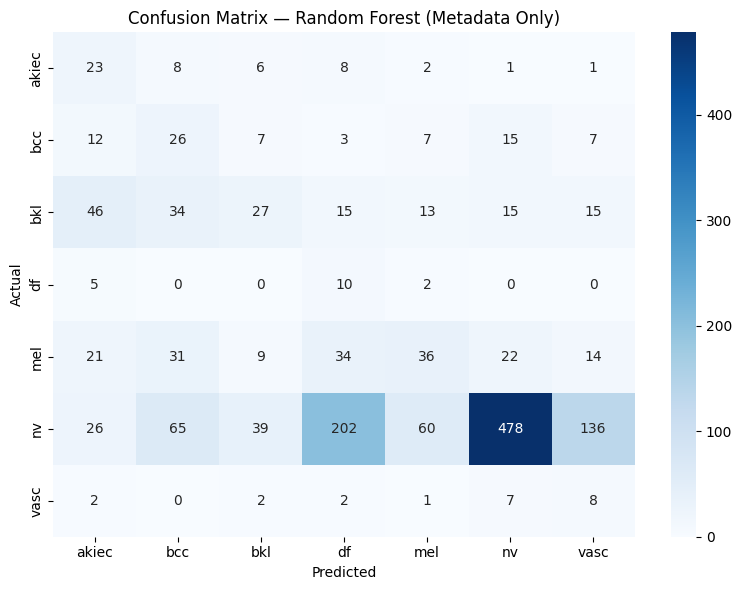


  XGBoost (Metadata Only) — Test Set Results
 • Accuracy           : 0.3752
 • Balanced Accuracy  : 0.3910   (fairer measure given class imbalance)
 • Recall (macro avg) : 0.3910   (catching real positive cases — critical in medical diagnosis)
 • F1 (macro avg)     : 0.2376

Per-class report:
              precision    recall  f1-score   support

       akiec       0.16      0.49      0.25        49
         bcc       0.14      0.35      0.20        77
         bkl       0.30      0.18      0.22       165
          df       0.04      0.71      0.08        17
         mel       0.30      0.23      0.26       167
          nv       0.90      0.42      0.58      1006
        vasc       0.04      0.36      0.08        22

    accuracy                           0.38      1503
   macro avg       0.27      0.39      0.24      1503
weighted avg       0.68      0.38      0.46      1503



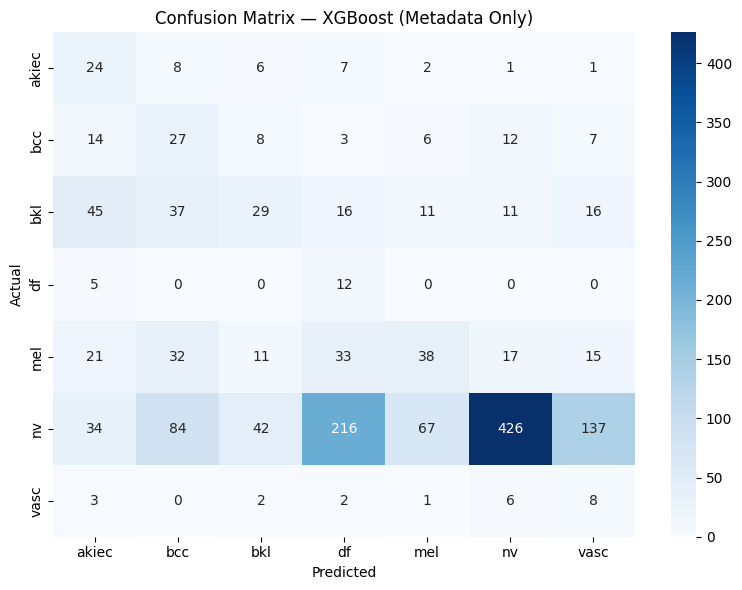


✅ PHASE 2 COMPLETE — baseline model(s) and label encoder saved to: /kaggle/working/artifacts/models


In [5]:
# ==============================================================================
# 17. LOAD CLEANED METADATA (output of Cell 2)
# ==============================================================================
cleaned_path = CONFIG["ARTIFACTS_DIR"] / "ham10000_cleaned_metadata.csv"
metadata = pd.read_csv(cleaned_path)

print(f" • Loaded cleaned metadata : {metadata.shape}")
print(f" • Columns                 : {list(metadata.columns)}")

# ==============================================================================
# 18. ENCODE THE TARGET LABEL (dx: 7 text codes -> 7 numbers)
# ==============================================================================
label_encoder = LabelEncoder()
metadata["dx_encoded"] = label_encoder.fit_transform(metadata[CONFIG["TARGET_COL"]])

print("\nLabel mapping (code -> encoded number):")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls}  ->  {i}   ({DIAGNOSIS_DICT[cls]})")

# ==============================================================================
# 19. SELECT FEATURES — METADATA ONLY (no images in this baseline)
# ==============================================================================
feature_cols = CONFIG["METADATA_NUMERIC_COLS"] + CONFIG["METADATA_CATEGORICAL_COLS"]
X = metadata[feature_cols]
y = metadata["dx_encoded"]

print(f"\n • Features used : {feature_cols}")
print(f" • X shape        : {X.shape}")
print(f" • y shape        : {y.shape}")

# ==============================================================================
# 20. TRAIN / VALIDATION / TEST SPLIT (stratified — keeps class balance in each split)
# ==============================================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=(CONFIG["VAL_RATIO"] + CONFIG["TEST_RATIO"]),
    stratify=y,
    random_state=CONFIG["SEED"]
)

relative_test_size = CONFIG["TEST_RATIO"] / (CONFIG["VAL_RATIO"] + CONFIG["TEST_RATIO"])
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=relative_test_size,
    stratify=y_temp,
    random_state=CONFIG["SEED"]
)

print(f"\n • Train set : {X_train.shape[0]} rows")
print(f" • Val set   : {X_val.shape[0]} rows")
print(f" • Test set  : {X_test.shape[0]} rows")

# ==============================================================================
# 21. PREPROCESSING PIPELINE (scale numeric, one-hot encode categorical)
# ==============================================================================
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), CONFIG["METADATA_NUMERIC_COLS"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CONFIG["METADATA_CATEGORICAL_COLS"]),
])

# ==============================================================================
# 22. COMPUTE CLASS WEIGHTS (to counter the imbalance we saw in Cell 2's EDA)
# ==============================================================================
class_weights_array = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(zip(np.unique(y_train), class_weights_array))

print("\nClass weights (higher = rarer class, gets more attention during training):")
for cls_idx, w in class_weight_dict.items():
    print(f"  {label_encoder.classes_[cls_idx]}  ->  {w:.2f}")

# ==============================================================================
# 23. TRAIN RANDOM FOREST BASELINE
# ==============================================================================
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        class_weight=class_weight_dict,
        random_state=CONFIG["SEED"],
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
print("\n✅ Random Forest baseline trained.")

# ==============================================================================
# 24. TRAIN XGBOOST BASELINE (if available — for comparison)
# ==============================================================================
if XGB_AVAILABLE:
    sample_weights = np.array([class_weight_dict[label] for label in y_train])

    xgb_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", xgb.XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            objective="multi:softprob",
            num_class=CONFIG["NUM_CLASSES"],
            random_state=CONFIG["SEED"],
            eval_metric="mlogloss"
        ))
    ])
    xgb_pipeline.fit(X_train, y_train, classifier__sample_weight=sample_weights)
    print("✅ XGBoost baseline trained.")
else:
    print("⚠ XGBoost not installed — skipping (pip install xgboost to enable).")

# ==============================================================================
# 25. EVALUATION FUNCTION (reused for both models)
# ==============================================================================
def evaluate_model(pipeline, X_eval, y_eval, model_name: str) -> Dict[str, float]:
    y_pred = pipeline.predict(X_eval)

    acc = accuracy_score(y_eval, y_pred)
    bal_acc = balanced_accuracy_score(y_eval, y_pred)
    recall_macro = recall_score(y_eval, y_pred, average="macro")
    f1_macro = f1_score(y_eval, y_pred, average="macro")

    print(f"\n{'=' * 60}")
    print(f"  {model_name} — Test Set Results")
    print(f"{'=' * 60}")
    print(f" • Accuracy           : {acc:.4f}")
    print(f" • Balanced Accuracy  : {bal_acc:.4f}   (fairer measure given class imbalance)")
    print(f" • Recall (macro avg) : {recall_macro:.4f}   (catching real positive cases — critical in medical diagnosis)")
    print(f" • F1 (macro avg)     : {f1_macro:.4f}")

    print(f"\nPer-class report:")
    print(classification_report(
        y_eval, y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    ))

    cm = confusion_matrix(y_eval, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(CONFIG["PLOTS_DIR"] / f"confusion_matrix_{model_name.replace(' ', '_').lower()}.png", dpi=150)
    plt.show()

    return {"accuracy": acc, "balanced_accuracy": bal_acc, "recall_macro": recall_macro, "f1_macro": f1_macro}

# ==============================================================================
# 26. RUN EVALUATION ON TEST SET
# ==============================================================================
rf_results = evaluate_model(rf_pipeline, X_test, y_test, "Random Forest (Metadata Only)")

if XGB_AVAILABLE:
    xgb_results = evaluate_model(xgb_pipeline, X_test, y_test, "XGBoost (Metadata Only)")

# ==============================================================================
# 27. SAVE THE BEST BASELINE MODEL + LABEL ENCODER FOR LATER USE
# ==============================================================================
import joblib

joblib.dump(rf_pipeline, CONFIG["MODELS_DIR"] / "baseline_random_forest.pkl")
joblib.dump(label_encoder, CONFIG["MODELS_DIR"] / "label_encoder.pkl")

if XGB_AVAILABLE:
    joblib.dump(xgb_pipeline, CONFIG["MODELS_DIR"] / "baseline_xgboost.pkl")

print(f"\n✅ PHASE 2 COMPLETE — baseline model(s) and label encoder saved to: {CONFIG['MODELS_DIR']}")

 • Metadata reloaded : (10015, 12)
 • Train : 7010  |  Val : 1502  |  Test : 1503

✅ tf.data pipelines built.

Class weights for CNN training:
  akiec  ->  4.37
  bcc  ->  2.78
  bkl  ->  1.30
  df  ->  12.36
  mel  ->  1.29
  nv  ->  0.21
  vasc  ->  10.12
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_Skin_Lesion_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,442 (16.08 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


PHASE A: Training classification head (base model frozen)
Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.3473 - loss: 1.8062
Epoch 1: val_loss improved from None to 1.04729, saving model to /kaggle/working/artifacts/checkpoints/best_cnn_model.keras

Epoch 1: finished saving model to /kaggle/working/artifacts/checkpoints/best_cnn_model.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 286s 627ms/step - accuracy: 0.4110 - loss: 1.5691 - val_accuracy: 0.6032 - val_loss: 1.0473 - learning_rate: 0.0010
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.4730 - loss: 1.3437
Epoch 2: val_loss improved from 1.04729 to 1.01003, saving model to /kaggle/working/artifacts/checkpoints/best_cnn_model.keras

Epoch 2: finished saving model to /kaggle/working/artifacts/checkpoints/best_cnn_model.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 276s 628ms/step - accuracy: 0.4919 - loss: 1.3071 - val_accuracy: 0.6039 - val_loss: 1.0100 - learning_rate: 0.0010
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━

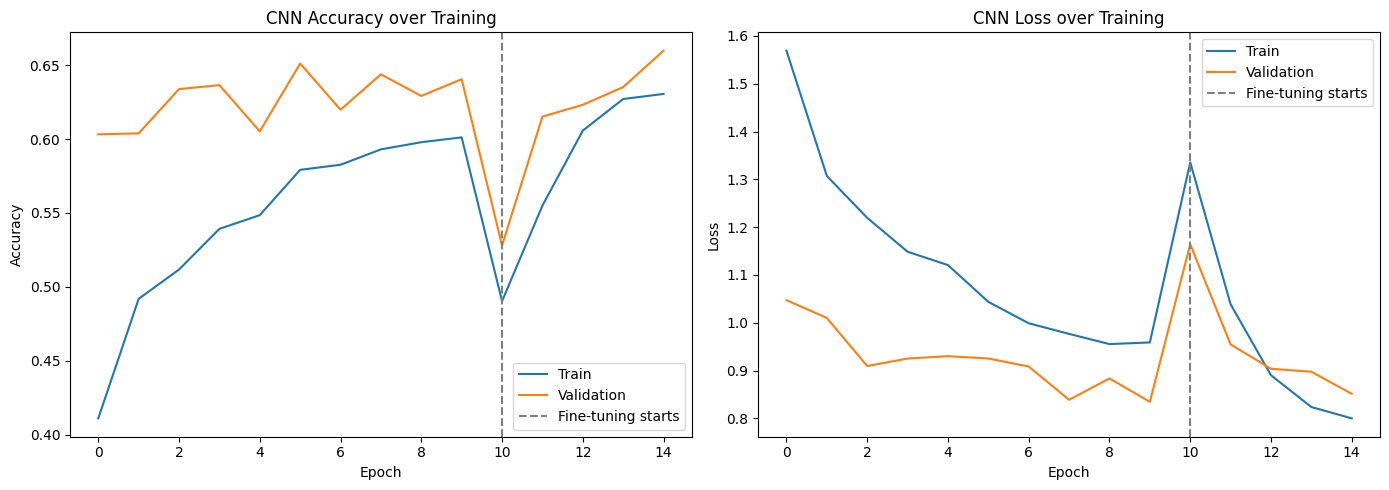

94/94 ━━━━━━━━━━━━━━━━━━━━ 46s 466ms/step

  CNN (EfficientNetB0, Images Only) — Test Set Results
 • Accuracy           : 0.5190
 • Balanced Accuracy  : 0.5619
 • Recall (macro avg) : 0.5619
 • F1 (macro avg)     : 0.4064

Per-class report:
              precision    recall  f1-score   support

       akiec       0.37      0.45      0.40        49
         bcc       0.52      0.42      0.46        77
         bkl       0.42      0.53      0.47       165
          df       0.09      0.47      0.15        17
         mel       0.23      0.66      0.34       167
          nv       0.97      0.50      0.66      1006
        vasc       0.23      0.91      0.36        22

    accuracy                           0.52      1503
   macro avg       0.40      0.56      0.41      1503
weighted avg       0.76      0.52      0.57      1503



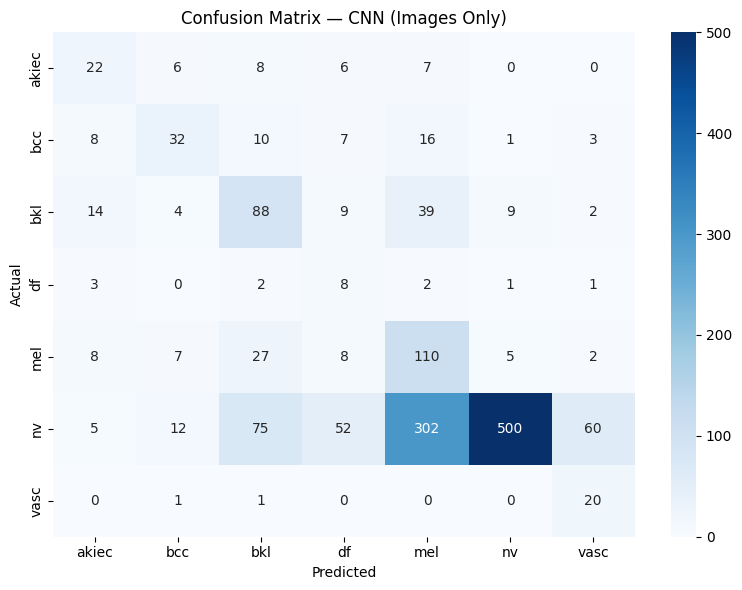


✅ PHASE 3 COMPLETE — CNN model saved to: /kaggle/working/artifacts/models


In [6]:
# ==============================================================================
# 28. RELOAD CLEANED METADATA + LABEL ENCODER (keeps this cell self-contained)
# ==============================================================================
import joblib

cleaned_path = CONFIG["ARTIFACTS_DIR"] / "ham10000_cleaned_metadata.csv"
metadata = pd.read_csv(cleaned_path)

label_encoder = joblib.load(CONFIG["MODELS_DIR"] / "label_encoder.pkl")
metadata["dx_encoded"] = label_encoder.transform(metadata[CONFIG["TARGET_COL"]])

print(f" • Metadata reloaded : {metadata.shape}")

# ==============================================================================
# 29. TRAIN / VAL / TEST SPLIT (same ratios + seed as Cell 3, now with image paths)
# ==============================================================================
X = metadata[["image_path"]].copy()
y = metadata["dx_encoded"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=(CONFIG["VAL_RATIO"] + CONFIG["TEST_RATIO"]),
    stratify=y,
    random_state=CONFIG["SEED"]
)
relative_test_size = CONFIG["TEST_RATIO"] / (CONFIG["VAL_RATIO"] + CONFIG["TEST_RATIO"])
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=relative_test_size,
    stratify=y_temp,
    random_state=CONFIG["SEED"]
)

train_paths = X_train["image_path"].astype(str).values
val_paths   = X_val["image_path"].astype(str).values
test_paths  = X_test["image_path"].astype(str).values

train_labels = y_train.values
val_labels   = y_val.values
test_labels  = y_test.values

print(f" • Train : {len(train_paths)}  |  Val : {len(val_paths)}  |  Test : {len(test_paths)}")

# ==============================================================================
# 30. tf.data PIPELINE — loads + resizes images on the fly (memory efficient)
# ==============================================================================
def load_and_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, CONFIG["IMAGE_SIZE"])
    image = tf.cast(image, tf.float32)  # EfficientNet expects raw [0-255], normalizes internally
    return image, label

def make_dataset(paths, labels, shuffle: bool = False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=CONFIG["SEED"])
    ds = ds.map(load_and_preprocess, num_parallel_calls=CONFIG["AUTOTUNE"])
    ds = ds.batch(CONFIG["BATCH_SIZE"])
    ds = ds.prefetch(CONFIG["AUTOTUNE"])
    return ds

train_ds = make_dataset(train_paths, train_labels, shuffle=True)
val_ds   = make_dataset(val_paths, val_labels, shuffle=False)
test_ds  = make_dataset(test_paths, test_labels, shuffle=False)

print("\n✅ tf.data pipelines built.")

# ==============================================================================
# 31. CLASS WEIGHTS (same logic as Cell 3, recomputed here for training)
# ==============================================================================
class_weights_array = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(zip(np.unique(train_labels).tolist(), class_weights_array.tolist()))

print("\nClass weights for CNN training:")
for cls_idx, w in class_weight_dict.items():
    print(f"  {label_encoder.classes_[cls_idx]}  ->  {w:.2f}")

# ==============================================================================
# 32. DATA AUGMENTATION (only active during training, off during val/test/inference)
# ==============================================================================
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name="data_augmentation")

# ==============================================================================
# 33. BUILD THE MODEL — EfficientNetB0 backbone (frozen) + custom classification head
# ==============================================================================
from keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=CONFIG["IMAGE_SIZE"] + (CONFIG["IMAGE_CHANNELS"],)
)
base_model.trainable = False  # freeze pretrained weights for the first training phase

inputs = keras.Input(shape=CONFIG["IMAGE_SIZE"] + (CONFIG["IMAGE_CHANNELS"],))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(CONFIG["NUM_CLASSES"], activation="softmax")(x)

cnn_model = keras.Model(inputs, outputs, name="EfficientNetB0_Skin_Lesion_CNN")

cnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=CONFIG["INITIAL_LR"]),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

# ==============================================================================
# 34. CALLBACKS
# ==============================================================================
class MemoryCleanupCallback(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()

model_callbacks = [
    callbacks.ModelCheckpoint(
        filepath=str(CONFIG["CHECKPOINT_DIR"] / "best_cnn_model.keras"),
        monitor="val_loss", save_best_only=True, verbose=1
    ),
    callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
    MemoryCleanupCallback(),   # <-- add the instance here
]
  

# ==============================================================================
# 35. PHASE A — TRAIN WITH FROZEN BASE (fast, teaches the new head)
# ==============================================================================
print("\n" + "=" * 75)
print("PHASE A: Training classification head (base model frozen)")
print("=" * 75)

history_phase_a = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=model_callbacks
)

# ==============================================================================
# 36. PHASE B — FINE-TUNE: unfreeze top layers of the backbone, train with lower LR
# ==============================================================================
print("\n" + "=" * 75)
print("PHASE B: Fine-tuning top layers of EfficientNetB0")
print("=" * 75)

base_model.trainable = True
fine_tune_at = len(base_model.layers) - 30  # unfreeze only the last 30 layers
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

cnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=CONFIG["INITIAL_LR"] / 10),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_phase_b = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=model_callbacks
)

# ==============================================================================
# 37. PLOT TRAINING CURVES (both phases combined)
# ==============================================================================
def combine_histories(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

full_history = combine_histories(history_phase_a, history_phase_b)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(full_history["accuracy"], label="Train")
axes[0].plot(full_history["val_accuracy"], label="Validation")
axes[0].axvline(x=10, color="gray", linestyle="--", label="Fine-tuning starts")
axes[0].set_title("CNN Accuracy over Training")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(full_history["loss"], label="Train")
axes[1].plot(full_history["val_loss"], label="Validation")
axes[1].axvline(x=10, color="gray", linestyle="--", label="Fine-tuning starts")
axes[1].set_title("CNN Loss over Training")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig(CONFIG["PLOTS_DIR"] / "cnn_training_curves.png", dpi=150)
plt.show()

# ==============================================================================
# 38. EVALUATE ON TEST SET
# ==============================================================================
y_pred_probs = cnn_model.predict(test_ds)
y_pred_cnn = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(test_labels, y_pred_cnn)
bal_acc = balanced_accuracy_score(test_labels, y_pred_cnn)
recall_macro = recall_score(test_labels, y_pred_cnn, average="macro")
f1_macro = f1_score(test_labels, y_pred_cnn, average="macro")

print(f"\n{'=' * 60}")
print("  CNN (EfficientNetB0, Images Only) — Test Set Results")
print(f"{'=' * 60}")
print(f" • Accuracy           : {acc:.4f}")
print(f" • Balanced Accuracy  : {bal_acc:.4f}")
print(f" • Recall (macro avg) : {recall_macro:.4f}")
print(f" • F1 (macro avg)     : {f1_macro:.4f}")

print(f"\nPer-class report:")
print(classification_report(
    test_labels, y_pred_cnn,
    target_names=label_encoder.classes_,
    zero_division=0
))

cm = confusion_matrix(test_labels, y_pred_cnn)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Confusion Matrix — CNN (Images Only)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(CONFIG["PLOTS_DIR"] / "confusion_matrix_cnn.png", dpi=150)
plt.show()

# ==============================================================================
# 39. SAVE THE TRAINED CNN
# ==============================================================================
cnn_model.save(CONFIG["MODELS_DIR"] / "cnn_efficientnetb0_final.keras")

print(f"\n✅ PHASE 3 COMPLETE — CNN model saved to: {CONFIG['MODELS_DIR']}")

 • Metadata reloaded : (10015, 12)
 • CNN reloaded      : EfficientNetB0_Skin_Lesion_CNN
 • Train : 7010  |  Val : 1502  |  Test : 1503

 • Feature extractor output shape : (None, 1280)
 • Extracting train embeddings (7010 images)...
439/439 ━━━━━━━━━━━━━━━━━━━━ 199s 448ms/step
 • Extracting val embeddings (1502 images)...
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 438ms/step
 • Extracting test embeddings (1503 images)...
94/94 ━━━━━━━━━━━━━━━━━━━━ 46s 492ms/step

 • Embedding shape per image : 1280
 • Metadata feature shape : 19

 • Fused feature vector size : 1299  (1280 image + 19 metadata)


Model: "Fusion_Image_Metadata_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fused_features (InputLayer)     │ (None, 1299)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       332,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 350,727 (1.34 MB)

 Trainable params: 350,215 (1.34 MB)

 Non-trainable params: 512 (2.00 KB)


TRAINING FUSION MODEL (image embeddings + patient metadata)
Epoch 1/40
 42/220 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3213 - loss: 2.6599

I0000 00:00:1789129679.770038     145 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3722 - loss: 2.0675
Epoch 1: val_loss improved from None to 0.93087, saving model to /kaggle/working/artifacts/checkpoints/best_fusion_model.keras

Epoch 1: finished saving model to /kaggle/working/artifacts/checkpoints/best_fusion_model.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.4087 - loss: 1.7436 - val_accuracy: 0.6165 - val_loss: 0.9309 - learning_rate: 0.0010
Epoch 2/40
208/220 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5082 - loss: 1.2520
Epoch 2: val_loss did not improve from 0.93087
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5247 - loss: 1.2067 - val_accuracy: 0.6039 - val_loss: 1.0096 - learning_rate: 0.0010
Epoch 3/40
215/220 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5615 - loss: 1.0701
Epoch 3: val_loss did not improve from 0.93087
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5628 - loss: 1.0552 - val_accuracy: 0.6158 - val_loss: 0.9771 - learning_rate: 0.0010
Epoch 4/40


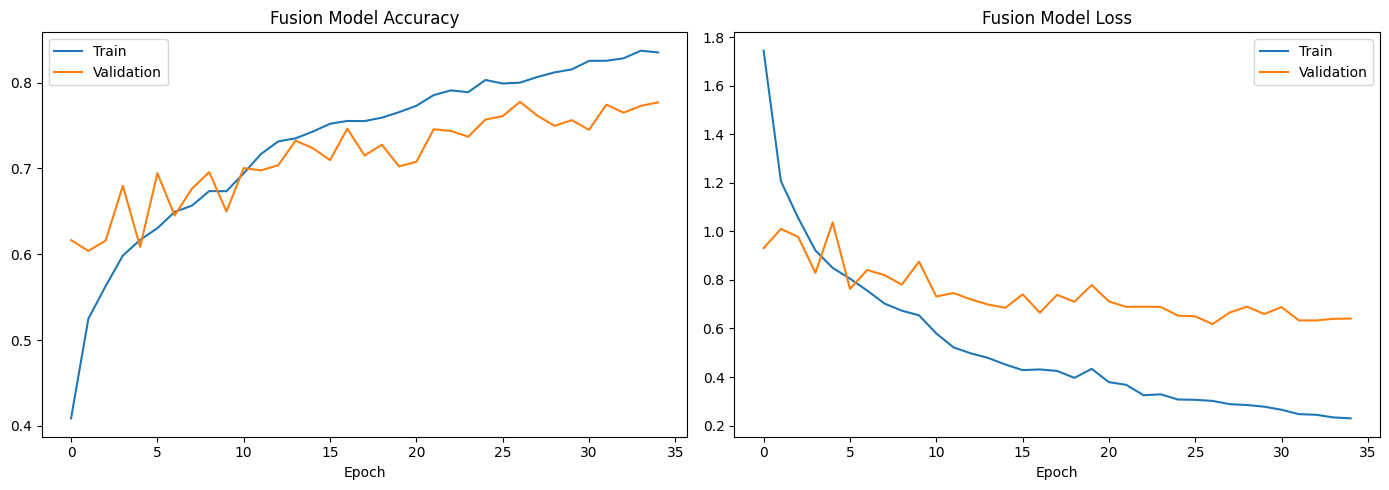

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

  FUSION MODEL (Image + Metadata) — Test Set Results
 • Accuracy           : 0.7598
 • Balanced Accuracy  : 0.7071
 • Recall (macro avg) : 0.7071
 • F1 (macro avg)     : 0.6481

Per-class report:
              precision    recall  f1-score   support

       akiec       0.63      0.65      0.64        49
         bcc       0.54      0.75      0.63        77
         bkl       0.57      0.68      0.62       165
          df       0.52      0.71      0.60        17
         mel       0.43      0.68      0.53       167
          nv       0.96      0.79      0.87      1006
        vasc       0.62      0.68      0.65        22

    accuracy                           0.76      1503
   macro avg       0.61      0.71      0.65      1503
weighted avg       0.81      0.76      0.78      1503



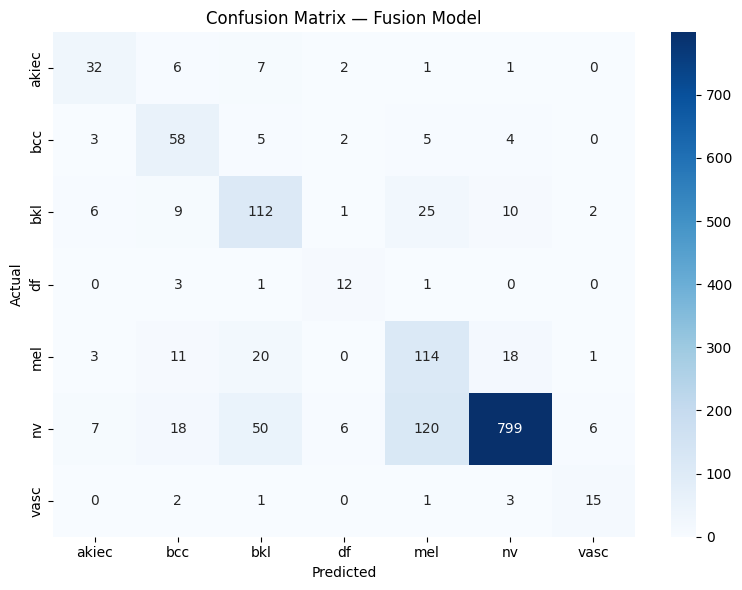


✅ PHASE 4 COMPLETE — fusion model saved to: /kaggle/working/artifacts/models


In [7]:
# ==============================================================================
# 40. RELOAD EVERYTHING NEEDED (fresh kernel — nothing is in memory yet)
# ==============================================================================
import joblib
from keras.models import load_model

cleaned_path = CONFIG["ARTIFACTS_DIR"] / "ham10000_cleaned_metadata.csv"
metadata = pd.read_csv(cleaned_path)

label_encoder = joblib.load(CONFIG["MODELS_DIR"] / "label_encoder.pkl")
metadata["dx_encoded"] = label_encoder.transform(metadata[CONFIG["TARGET_COL"]])

cnn_model = load_model(CONFIG["CHECKPOINT_DIR"] / "best_cnn_model.keras")

print(f" • Metadata reloaded : {metadata.shape}")
print(f" • CNN reloaded      : {cnn_model.name}")

# ==============================================================================
# 41. RECREATE THE EXACT SAME TRAIN/VAL/TEST SPLIT (same seed = same rows)
# ==============================================================================
X_all = metadata.copy()
y_all = metadata["dx_encoded"]

train_df, temp_df, y_train, y_temp = train_test_split(
    X_all, y_all,
    test_size=(CONFIG["VAL_RATIO"] + CONFIG["TEST_RATIO"]),
    stratify=y_all,
    random_state=CONFIG["SEED"]
)
relative_test_size = CONFIG["TEST_RATIO"] / (CONFIG["VAL_RATIO"] + CONFIG["TEST_RATIO"])
val_df, test_df, y_val, y_test = train_test_split(
    temp_df, y_temp,
    test_size=relative_test_size,
    stratify=y_temp,
    random_state=CONFIG["SEED"]
)

print(f" • Train : {len(train_df)}  |  Val : {len(val_df)}  |  Test : {len(test_df)}")

# ==============================================================================
# 42. BUILD A FEATURE-EXTRACTOR MODEL (CNN, minus the final classification layers)
# ==============================================================================
feature_extractor = keras.Model(
    inputs=cnn_model.input,
    outputs=cnn_model.get_layer("global_average_pooling2d").output,
    name="cnn_feature_extractor"
)
feature_extractor.trainable = False  # frozen — we're only extracting, not training here

print(f"\n • Feature extractor output shape : {feature_extractor.output_shape}")

# ==============================================================================
# 43. IMAGE LOADING FUNCTION (same as Cell 4, no label needed here)
# ==============================================================================
def load_image_only(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, CONFIG["IMAGE_SIZE"])
    image = tf.cast(image, tf.float32)
    return image

def make_image_dataset(paths):
    ds = tf.data.Dataset.from_tensor_slices(paths.astype(str))
    ds = ds.map(load_image_only, num_parallel_calls=CONFIG["AUTOTUNE"])
    ds = ds.batch(CONFIG["BATCH_SIZE"])
    ds = ds.prefetch(CONFIG["AUTOTUNE"])
    return ds

# ==============================================================================
# 44. EXTRACT IMAGE EMBEDDINGS FOR EACH SPLIT (runs once, then reused for all epochs)
# ==============================================================================
def extract_embeddings(df, split_name):
    ds = make_image_dataset(df["image_path"].values)
    print(f" • Extracting {split_name} embeddings ({len(df)} images)...")
    embeddings = feature_extractor.predict(ds, verbose=1)
    return embeddings

train_embeddings = extract_embeddings(train_df, "train")
val_embeddings   = extract_embeddings(val_df, "val")
test_embeddings  = extract_embeddings(test_df, "test")

print(f"\n • Embedding shape per image : {train_embeddings.shape[1]}")
gc.collect()

# ==============================================================================
# 45. BUILD METADATA FEATURES (same preprocessing logic as Cell 3's baseline)
# ==============================================================================
metadata_preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), CONFIG["METADATA_NUMERIC_COLS"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CONFIG["METADATA_CATEGORICAL_COLS"]),
])

train_meta_features = metadata_preprocessor.fit_transform(
    train_df[CONFIG["METADATA_NUMERIC_COLS"] + CONFIG["METADATA_CATEGORICAL_COLS"]]
)
val_meta_features = metadata_preprocessor.transform(
    val_df[CONFIG["METADATA_NUMERIC_COLS"] + CONFIG["METADATA_CATEGORICAL_COLS"]]
)
test_meta_features = metadata_preprocessor.transform(
    test_df[CONFIG["METADATA_NUMERIC_COLS"] + CONFIG["METADATA_CATEGORICAL_COLS"]]
)

# OneHotEncoder can return sparse matrices — ensure dense arrays for concatenation
train_meta_features = np.asarray(train_meta_features.todense() if hasattr(train_meta_features, "todense") else train_meta_features)
val_meta_features   = np.asarray(val_meta_features.todense() if hasattr(val_meta_features, "todense") else val_meta_features)
test_meta_features  = np.asarray(test_meta_features.todense() if hasattr(test_meta_features, "todense") else test_meta_features)

print(f" • Metadata feature shape : {train_meta_features.shape[1]}")

# ==============================================================================
# 46. FUSE: CONCATENATE IMAGE EMBEDDINGS + METADATA FEATURES
# ==============================================================================
X_train_fused = np.concatenate([train_embeddings, train_meta_features], axis=1)
X_val_fused   = np.concatenate([val_embeddings, val_meta_features], axis=1)
X_test_fused  = np.concatenate([test_embeddings, test_meta_features], axis=1)

y_train_arr = train_df["dx_encoded"].values
y_val_arr   = val_df["dx_encoded"].values
y_test_arr  = test_df["dx_encoded"].values

print(f"\n • Fused feature vector size : {X_train_fused.shape[1]}  "
      f"({train_embeddings.shape[1]} image + {train_meta_features.shape[1]} metadata)")

# ==============================================================================
# 47. CLASS WEIGHTS (same logic as before)
# ==============================================================================
class_weights_array = class_weight.compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train_arr), y=y_train_arr
)
class_weight_dict = dict(zip(np.unique(y_train_arr).tolist(), class_weights_array.tolist()))

# ==============================================================================
# 48. BUILD THE FUSION HEAD (a small dense network on top of the fused vector)
# ==============================================================================
fusion_input = keras.Input(shape=(X_train_fused.shape[1],), name="fused_features")
x = layers.Dense(256, activation="relu")(fusion_input)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)
fusion_output = layers.Dense(CONFIG["NUM_CLASSES"], activation="softmax")(x)

fusion_model = keras.Model(fusion_input, fusion_output, name="Fusion_Image_Metadata_Model")

fusion_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fusion_model.summary()

# ==============================================================================
# 49. CALLBACKS
# ==============================================================================
class MemoryCleanupCallback(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()

fusion_callbacks = [
    callbacks.ModelCheckpoint(
        filepath=str(CONFIG["CHECKPOINT_DIR"] / "best_fusion_model.keras"),
        monitor="val_loss", save_best_only=True, verbose=1
    ),
    callbacks.EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1
    ),
    MemoryCleanupCallback(),
]

# ==============================================================================
# 50. TRAIN THE FUSION MODEL (fast — training on small feature vectors, not raw images)
# ==============================================================================
print("\n" + "=" * 75)
print("TRAINING FUSION MODEL (image embeddings + patient metadata)")
print("=" * 75)

fusion_history = fusion_model.fit(
    X_train_fused, y_train_arr,
    validation_data=(X_val_fused, y_val_arr),
    epochs=40,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=fusion_callbacks
)

# ==============================================================================
# 51. TRAINING CURVES
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fusion_history.history["accuracy"], label="Train")
axes[0].plot(fusion_history.history["val_accuracy"], label="Validation")
axes[0].set_title("Fusion Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(fusion_history.history["loss"], label="Train")
axes[1].plot(fusion_history.history["val_loss"], label="Validation")
axes[1].set_title("Fusion Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(CONFIG["PLOTS_DIR"] / "fusion_training_curves.png", dpi=150)
plt.show()

# ==============================================================================
# 52. EVALUATE ON TEST SET
# ==============================================================================
y_pred_probs = fusion_model.predict(X_test_fused)
y_pred_fusion = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_test_arr, y_pred_fusion)
bal_acc = balanced_accuracy_score(y_test_arr, y_pred_fusion)
recall_macro = recall_score(y_test_arr, y_pred_fusion, average="macro")
f1_macro = f1_score(y_test_arr, y_pred_fusion, average="macro")

print(f"\n{'=' * 60}")
print("  FUSION MODEL (Image + Metadata) — Test Set Results")
print(f"{'=' * 60}")
print(f" • Accuracy           : {acc:.4f}")
print(f" • Balanced Accuracy  : {bal_acc:.4f}")
print(f" • Recall (macro avg) : {recall_macro:.4f}")
print(f" • F1 (macro avg)     : {f1_macro:.4f}")

print(f"\nPer-class report:")
print(classification_report(
    y_test_arr, y_pred_fusion,
    target_names=label_encoder.classes_,
    zero_division=0
))

cm = confusion_matrix(y_test_arr, y_pred_fusion)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Confusion Matrix — Fusion Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(CONFIG["PLOTS_DIR"] / "confusion_matrix_fusion.png", dpi=150)
plt.show()

# ==============================================================================
# 53. SAVE THE FUSION MODEL + METADATA PREPROCESSOR
# ==============================================================================
fusion_model.save(CONFIG["MODELS_DIR"] / "fusion_model_final.keras")
joblib.dump(metadata_preprocessor, CONFIG["MODELS_DIR"] / "metadata_preprocessor.pkl")

print(f"\n✅ PHASE 4 COMPLETE — fusion model saved to: {CONFIG['MODELS_DIR']}")

✅ All models reloaded.
 • Test set : 1503 rows (identical across all 3 models)
94/94 ━━━━━━━━━━━━━━━━━━━━ 50s 513ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 50s 506ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

✅ Predictions generated for all 3 models on the identical test set.

FINAL MODEL COMPARISON
                         Model  Accuracy  Balanced Accuracy  Recall (macro)  Precision (macro)  F1 (macro)
Random Forest\n(Metadata Only)  0.404524           0.373325        0.373325           0.270800    0.242036
            CNN\n(Images Only)  0.648037           0.598056        0.598056           0.489931    0.515038
   Fusion\n(Images + Metadata)  0.759814           0.707095        0.707095           0.610218    0.648066


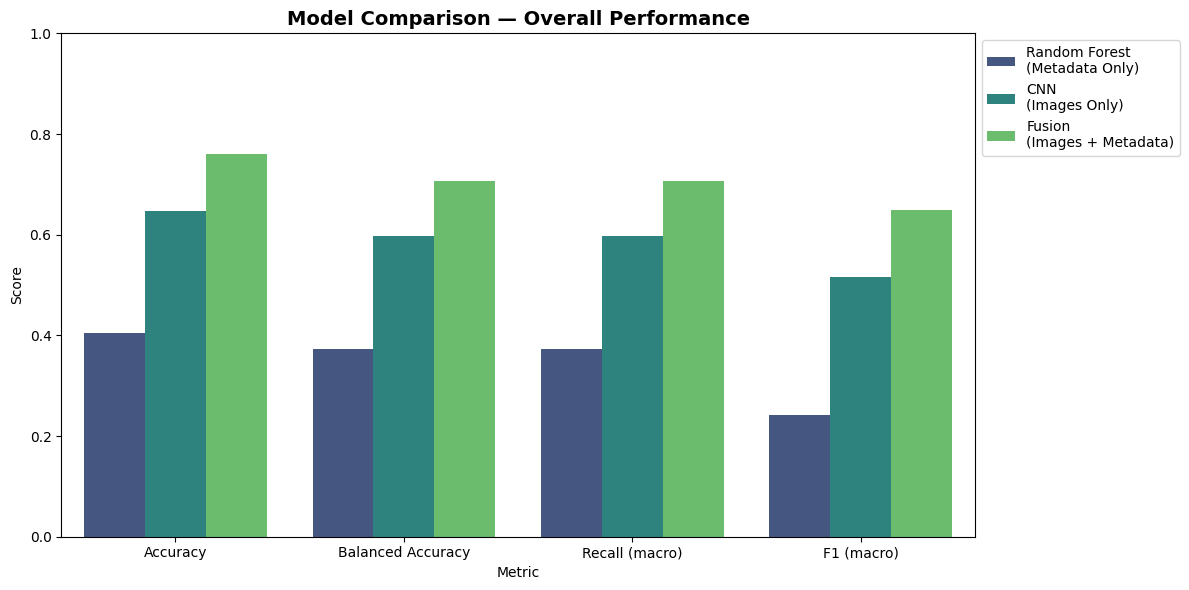

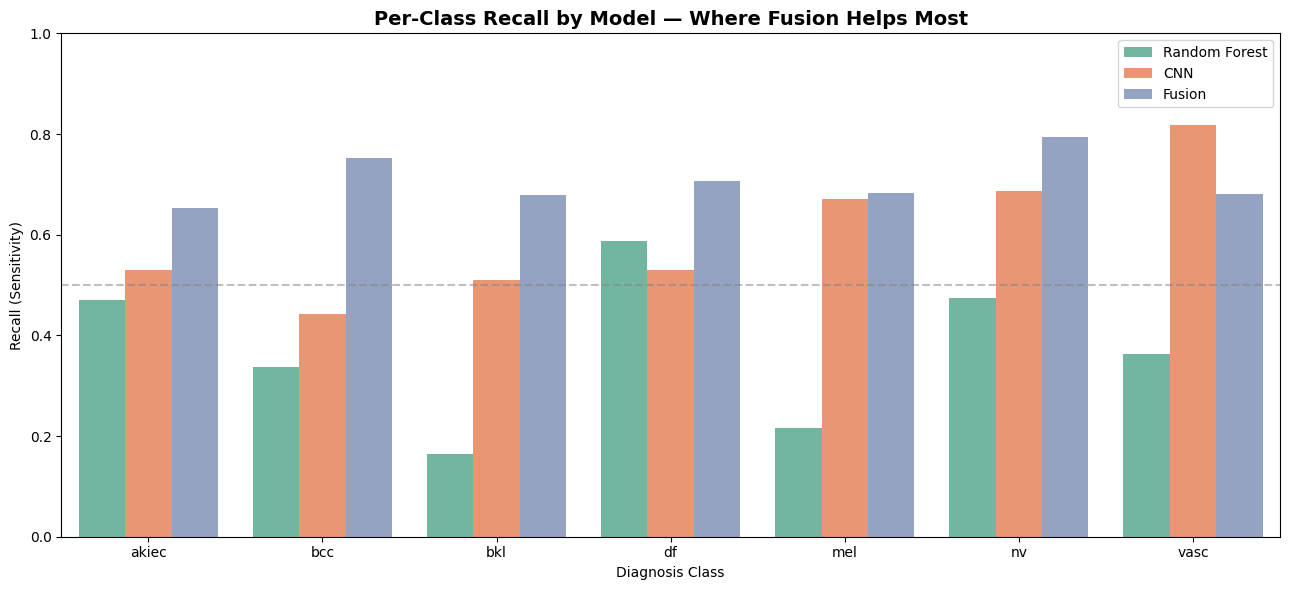

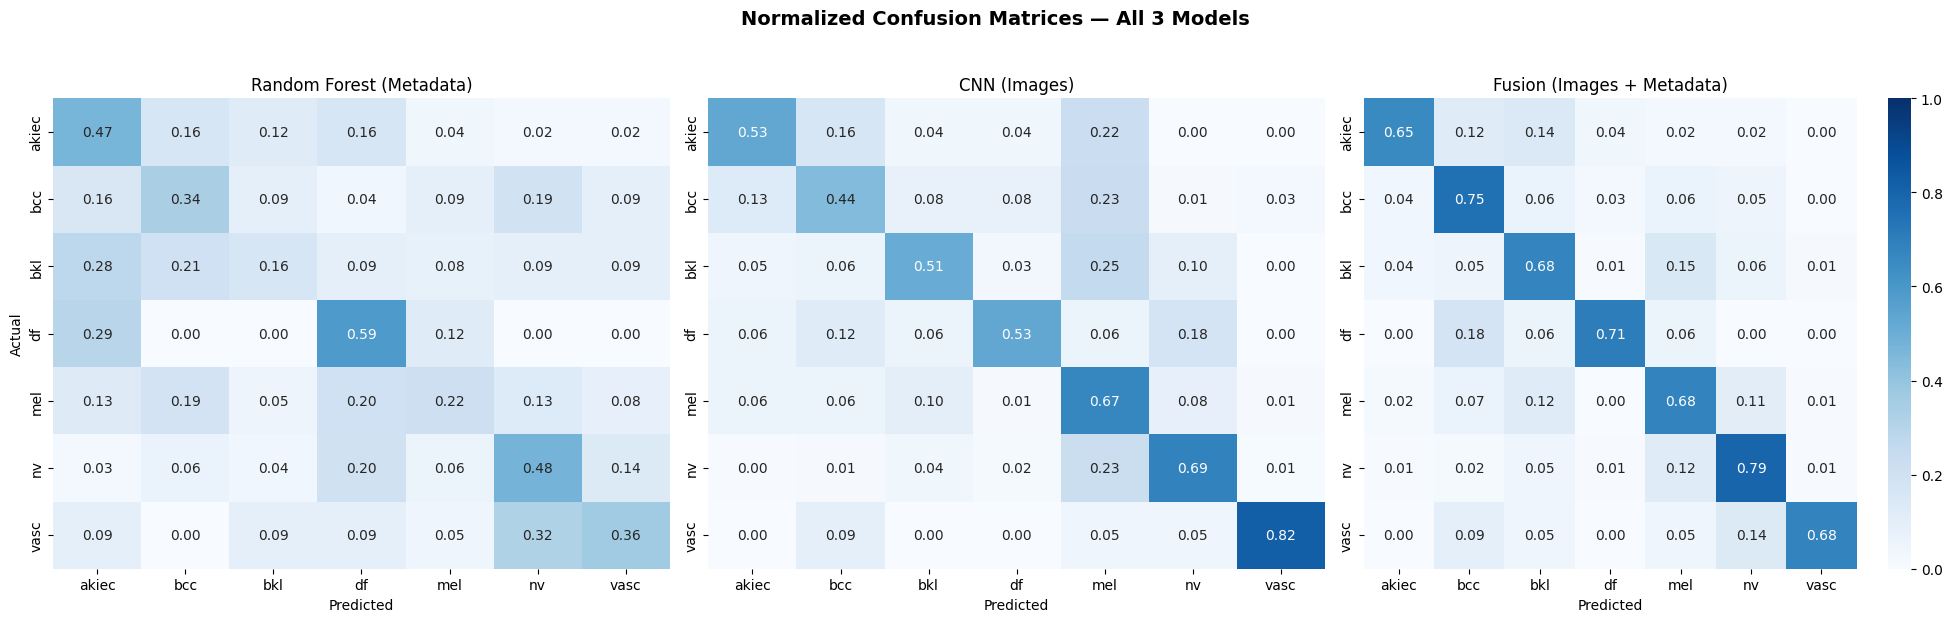

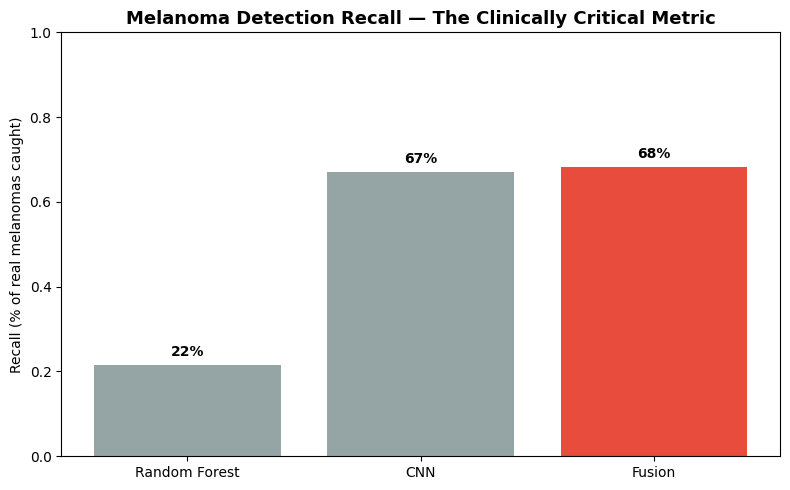


✅ PHASE 5 COMPLETE — all comparison visuals saved to: /kaggle/working/artifacts/plots
 • Summary table saved to: /kaggle/working/artifacts/final_model_comparison.csv


In [8]:
# ==============================================================================
# 54. RELOAD EVERYTHING NEEDED FOR FINAL EVALUATION
# ==============================================================================
import joblib
from keras.models import load_model

cleaned_path = CONFIG["ARTIFACTS_DIR"] / "ham10000_cleaned_metadata.csv"
metadata = pd.read_csv(cleaned_path)

label_encoder = joblib.load(CONFIG["MODELS_DIR"] / "label_encoder.pkl")
metadata["dx_encoded"] = label_encoder.transform(metadata[CONFIG["TARGET_COL"]])

rf_pipeline = joblib.load(CONFIG["MODELS_DIR"] / "baseline_random_forest.pkl")
metadata_preprocessor = joblib.load(CONFIG["MODELS_DIR"] / "metadata_preprocessor.pkl")
cnn_model = load_model(CONFIG["CHECKPOINT_DIR"] / "best_cnn_model.keras")
fusion_model = load_model(CONFIG["CHECKPOINT_DIR"] / "best_fusion_model.keras")

print("✅ All models reloaded.")

# ==============================================================================
# 55. RECREATE THE EXACT SAME TEST SPLIT (identical seed/stratify = same rows)
# ==============================================================================
X_all = metadata.copy()
y_all = metadata["dx_encoded"]

train_df, temp_df, y_train, y_temp = train_test_split(
    X_all, y_all,
    test_size=(CONFIG["VAL_RATIO"] + CONFIG["TEST_RATIO"]),
    stratify=y_all, random_state=CONFIG["SEED"]
)
relative_test_size = CONFIG["TEST_RATIO"] / (CONFIG["VAL_RATIO"] + CONFIG["TEST_RATIO"])
val_df, test_df, y_val, y_test = train_test_split(
    temp_df, y_temp, test_size=relative_test_size,
    stratify=y_temp, random_state=CONFIG["SEED"]
)

y_test_arr = test_df["dx_encoded"].values
print(f" • Test set : {len(test_df)} rows (identical across all 3 models)")

# ==============================================================================
# 56. GENERATE PREDICTIONS — MODEL 1: RANDOM FOREST (metadata only)
# ==============================================================================
feature_cols = CONFIG["METADATA_NUMERIC_COLS"] + CONFIG["METADATA_CATEGORICAL_COLS"]
X_test_meta = test_df[feature_cols]
y_pred_rf = rf_pipeline.predict(X_test_meta)

# ==============================================================================
# 57. GENERATE PREDICTIONS — MODEL 2: CNN (images only)
# ==============================================================================
def load_image_only(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, CONFIG["IMAGE_SIZE"])
    return tf.cast(image, tf.float32)

def make_image_dataset(paths):
    ds = tf.data.Dataset.from_tensor_slices(paths.astype(str))
    ds = ds.map(load_image_only, num_parallel_calls=CONFIG["AUTOTUNE"])
    ds = ds.batch(CONFIG["BATCH_SIZE"])
    ds = ds.prefetch(CONFIG["AUTOTUNE"])
    return ds

test_image_ds = make_image_dataset(test_df["image_path"].values)
y_pred_cnn_probs = cnn_model.predict(test_image_ds, verbose=1)
y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)

# ==============================================================================
# 58. GENERATE PREDICTIONS — MODEL 3: FUSION (images + metadata)
# ==============================================================================
feature_extractor = keras.Model(
    inputs=cnn_model.input,
    outputs=cnn_model.get_layer("global_average_pooling2d").output
)
test_embeddings = feature_extractor.predict(test_image_ds, verbose=1)

test_meta_features = metadata_preprocessor.transform(X_test_meta)
test_meta_features = np.asarray(
    test_meta_features.todense() if hasattr(test_meta_features, "todense") else test_meta_features
)

X_test_fused = np.concatenate([test_embeddings, test_meta_features], axis=1)
y_pred_fusion_probs = fusion_model.predict(X_test_fused)
y_pred_fusion = np.argmax(y_pred_fusion_probs, axis=1)

print("\n✅ Predictions generated for all 3 models on the identical test set.")

# ==============================================================================
# 59. BUILD A UNIFIED RESULTS SUMMARY TABLE
# ==============================================================================
def compute_metrics(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Recall (macro)": recall_score(y_true, y_pred, average="macro"),
        "Precision (macro)": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_true, y_pred, average="macro"),
    }

results_summary = pd.DataFrame([
    compute_metrics(y_test_arr, y_pred_rf, "Random Forest\n(Metadata Only)"),
    compute_metrics(y_test_arr, y_pred_cnn, "CNN\n(Images Only)"),
    compute_metrics(y_test_arr, y_pred_fusion, "Fusion\n(Images + Metadata)"),
])

print("\n" + "=" * 75)
print("FINAL MODEL COMPARISON")
print("=" * 75)
print(results_summary.to_string(index=False))

results_summary.to_csv(CONFIG["ARTIFACTS_DIR"] / "final_model_comparison.csv", index=False)

# ==============================================================================
# 60. VISUAL 1 — OVERALL METRICS COMPARISON (grouped bar chart)
# ==============================================================================
metrics_to_plot = ["Accuracy", "Balanced Accuracy", "Recall (macro)", "F1 (macro)"]
plot_df = results_summary.melt(id_vars="Model", value_vars=metrics_to_plot,
                                 var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model", palette="viridis")
plt.title("Model Comparison — Overall Performance", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="", loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(CONFIG["PLOTS_DIR"] / "final_comparison_overall.png", dpi=150)
plt.show()

# ==============================================================================
# 61. VISUAL 2 — PER-CLASS RECALL COMPARISON (the melanoma story, visualized)
# ==============================================================================
def per_class_recall(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return cm.diagonal() / cm.sum(axis=1)

recall_rf = per_class_recall(y_test_arr, y_pred_rf)
recall_cnn = per_class_recall(y_test_arr, y_pred_cnn)
recall_fusion = per_class_recall(y_test_arr, y_pred_fusion)

per_class_df = pd.DataFrame({
    "Class": label_encoder.classes_,
    "Random Forest": recall_rf,
    "CNN": recall_cnn,
    "Fusion": recall_fusion,
}).melt(id_vars="Class", var_name="Model", value_name="Recall")

plt.figure(figsize=(13, 6))
sns.barplot(data=per_class_df, x="Class", y="Recall", hue="Model", palette="Set2")
plt.title("Per-Class Recall by Model — Where Fusion Helps Most", fontsize=14, fontweight="bold")
plt.ylabel("Recall (Sensitivity)")
plt.xlabel("Diagnosis Class")
plt.ylim(0, 1)
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
plt.legend(title="")
plt.tight_layout()
plt.savefig(CONFIG["PLOTS_DIR"] / "final_comparison_per_class_recall.png", dpi=150)
plt.show()

# ==============================================================================
# 62. VISUAL 3 — SIDE-BY-SIDE CONFUSION MATRICES
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, y_pred, title in zip(
    axes,
    [y_pred_rf, y_pred_cnn, y_pred_fusion],
    ["Random Forest (Metadata)", "CNN (Images)", "Fusion (Images + Metadata)"]
):
    cm = confusion_matrix(y_test_arr, y_pred)
    cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_normalized, annot=True, fmt=".2f", cmap="Blues", ax=ax,
        xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_,
        vmin=0, vmax=1, cbar=(ax == axes[-1])
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual" if ax == axes[0] else "")

plt.suptitle("Normalized Confusion Matrices — All 3 Models", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(CONFIG["PLOTS_DIR"] / "final_comparison_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# ==============================================================================
# 63. VISUAL 4 — MELANOMA-SPECIFIC FOCUS (most clinically important class)
# ==============================================================================
mel_idx = list(label_encoder.classes_).index("mel")

mel_metrics = pd.DataFrame({
    "Model": ["Random Forest", "CNN", "Fusion"],
    "Melanoma Recall": [recall_rf[mel_idx], recall_cnn[mel_idx], recall_fusion[mel_idx]],
})

plt.figure(figsize=(8, 5))
bars = plt.bar(mel_metrics["Model"], mel_metrics["Melanoma Recall"],
                color=["#e74c3c" if v == mel_metrics["Melanoma Recall"].max() else "#95a5a6"
                       for v in mel_metrics["Melanoma Recall"]])
plt.title("Melanoma Detection Recall — The Clinically Critical Metric", fontsize=13, fontweight="bold")
plt.ylabel("Recall (% of real melanomas caught)")
plt.ylim(0, 1)
for bar, val in zip(bars, mel_metrics["Melanoma Recall"]):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.0%}",
              ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(CONFIG["PLOTS_DIR"] / "final_comparison_melanoma_recall.png", dpi=150)
plt.show()

print(f"\n✅ PHASE 5 COMPLETE — all comparison visuals saved to: {CONFIG['PLOTS_DIR']}")
print(f" • Summary table saved to: {CONFIG['ARTIFACTS_DIR'] / 'final_model_comparison.csv'}")

 • Val set : 1502  |  Test set : 1503
Building validation features (used to fit calibration)...
94/94 ━━━━━━━━━━━━━━━━━━━━ 50s 509ms/step
Building test features (held out — used only for final evaluation)...
94/94 ━━━━━━━━━━━━━━━━━━━━ 46s 484ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


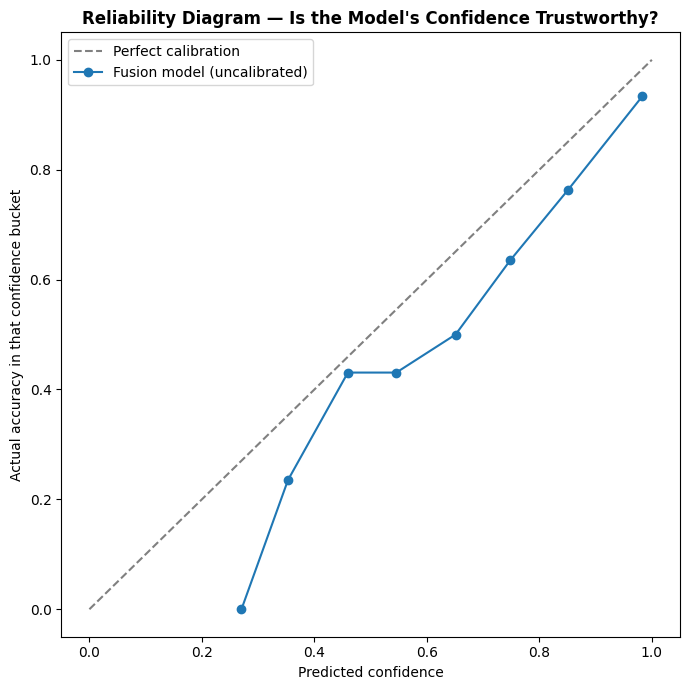


Interpretation guide:
 • Curve BELOW the diagonal  -> model is overconfident (says 90% sure, but often wrong)
 • Curve ABOVE the diagonal  -> model is underconfident
 • Curve ON the diagonal     -> well calibrated
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
 • Sanity check — max difference between reconstructed and original probs: 0.000000
   (should be a tiny number close to 0.0 — confirms logits extraction is correct)

 • Best temperature found : 1.591
   (T > 1 means the model was overconfident; T < 1 means underconfident; T = 1 means already well-calibrated)


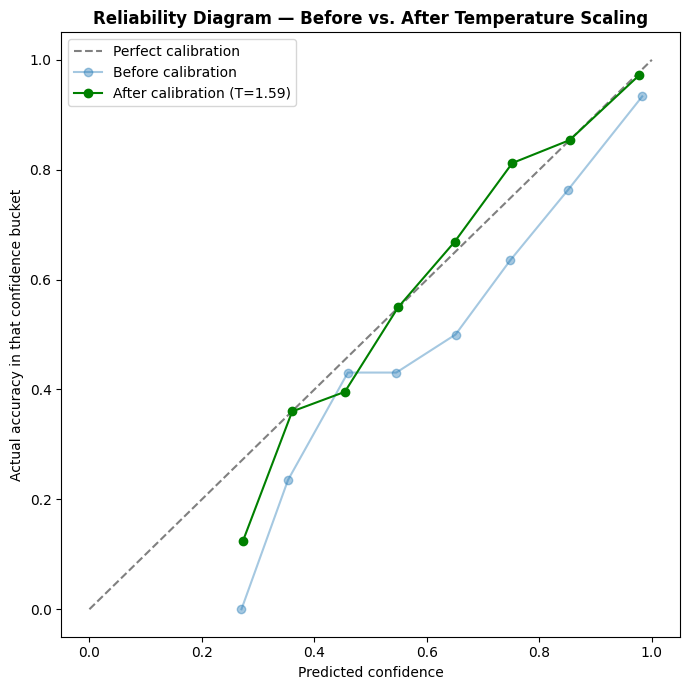


 • Test accuracy before calibration : 0.7598
 • Test accuracy after calibration  : 0.7598   (should now match — calibration only rescales confidence, not predictions)

CONFIDENCE THRESHOLDING — Trade-off Between Coverage and Reliability
 Confidence Threshold  Coverage (% of cases model answers)  Accuracy on Retained Cases  Macro Recall on Retained Cases
                  0.0                             1.000000                    0.759814                        0.707095
                  0.5                             0.850299                    0.822379                        0.770826
                  0.6                             0.741850                    0.866368                        0.806014
                  0.7                             0.634065                    0.908709                        0.830224
                  0.8                             0.518297                    0.946085                        0.862172
                  0.9                           

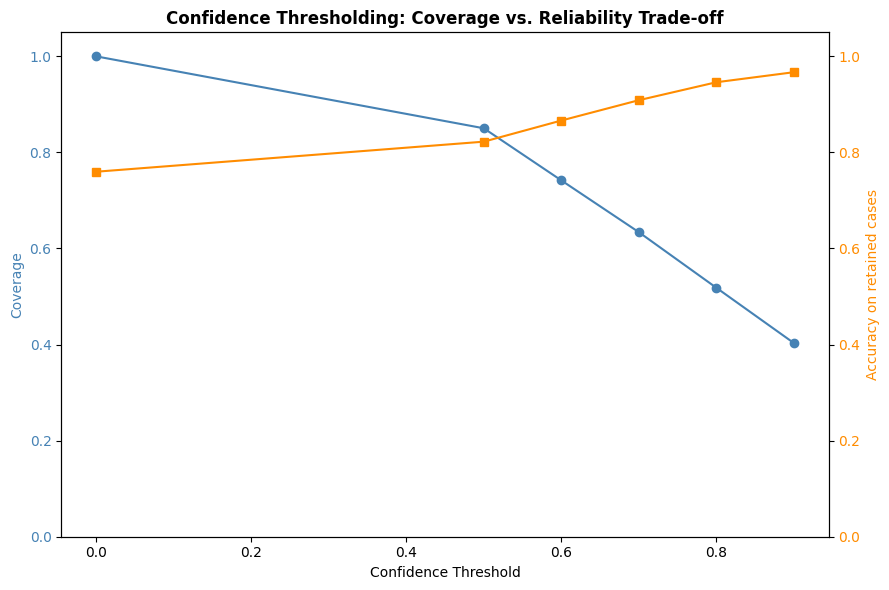


MELANOMA-SPECIFIC RELIABILITY AT DIFFERENT CONFIDENCE LEVELS
 • Threshold 0.0 : 267 melanoma flags, precision = 0.427
 • Threshold 0.5 : 199 melanoma flags, precision = 0.472
 • Threshold 0.7 : 81 melanoma flags, precision = 0.667
 • Threshold 0.9 : 15 melanoma flags, precision = 0.867

✅ CALIBRATION ANALYSIS COMPLETE (corrected)


In [9]:
# ==============================================================================
# 64. RELOAD FUSION MODEL + RECREATE TEST SET (self-contained, same as Cell 6)
# ==============================================================================
import joblib
from keras.models import load_model
from sklearn.calibration import calibration_curve

cleaned_path = CONFIG["ARTIFACTS_DIR"] / "ham10000_cleaned_metadata.csv"
metadata = pd.read_csv(cleaned_path)
label_encoder = joblib.load(CONFIG["MODELS_DIR"] / "label_encoder.pkl")
metadata["dx_encoded"] = label_encoder.transform(metadata[CONFIG["TARGET_COL"]])

metadata_preprocessor = joblib.load(CONFIG["MODELS_DIR"] / "metadata_preprocessor.pkl")
cnn_model = load_model(CONFIG["CHECKPOINT_DIR"] / "best_cnn_model.keras")
fusion_model = load_model(CONFIG["CHECKPOINT_DIR"] / "best_fusion_model.keras")

X_all = metadata.copy()
y_all = metadata["dx_encoded"]
train_df, temp_df, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=(CONFIG["VAL_RATIO"] + CONFIG["TEST_RATIO"]),
    stratify=y_all, random_state=CONFIG["SEED"]
)
relative_test_size = CONFIG["TEST_RATIO"] / (CONFIG["VAL_RATIO"] + CONFIG["TEST_RATIO"])
val_df, test_df, y_val, y_test = train_test_split(
    temp_df, y_temp, test_size=relative_test_size,
    stratify=y_temp, random_state=CONFIG["SEED"]
)
y_val_arr = val_df["dx_encoded"].values
y_test_arr = test_df["dx_encoded"].values

print(f" • Val set : {len(val_df)}  |  Test set : {len(test_df)}")

# ==============================================================================
# 65. BUILD FUSED FEATURES FOR VAL + TEST (needed for calibration fitting + eval)
# ==============================================================================
def load_image_only(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, CONFIG["IMAGE_SIZE"])
    return tf.cast(image, tf.float32)

def make_image_dataset(paths):
    ds = tf.data.Dataset.from_tensor_slices(paths.astype(str))
    ds = ds.map(load_image_only, num_parallel_calls=CONFIG["AUTOTUNE"])
    ds = ds.batch(CONFIG["BATCH_SIZE"])
    ds = ds.prefetch(CONFIG["AUTOTUNE"])
    return ds

feature_extractor = keras.Model(
    inputs=cnn_model.input,
    outputs=cnn_model.get_layer("global_average_pooling2d").output
)

def build_fused_features(df):
    ds = make_image_dataset(df["image_path"].values)
    embeddings = feature_extractor.predict(ds, verbose=1)
    meta_feats = metadata_preprocessor.transform(
        df[CONFIG["METADATA_NUMERIC_COLS"] + CONFIG["METADATA_CATEGORICAL_COLS"]]
    )
    meta_feats = np.asarray(meta_feats.todense() if hasattr(meta_feats, "todense") else meta_feats)
    return np.concatenate([embeddings, meta_feats], axis=1)

print("Building validation features (used to fit calibration)...")
X_val_fused = build_fused_features(val_df)
print("Building test features (held out — used only for final evaluation)...")
X_test_fused = build_fused_features(test_df)

# ==============================================================================
# 66. GET RAW (UNCALIBRATED) PROBABILITIES
# ==============================================================================
val_probs_raw = fusion_model.predict(X_val_fused)
test_probs_raw = fusion_model.predict(X_test_fused)

val_confidence_raw = val_probs_raw.max(axis=1)
val_pred_raw = val_probs_raw.argmax(axis=1)
val_correct = (val_pred_raw == y_val_arr).astype(int)

# ==============================================================================
# 67. RELIABILITY DIAGRAM — is the model's confidence trustworthy? (BEFORE calibration)
# ==============================================================================
prob_true, prob_pred = calibration_curve(val_correct, val_confidence_raw, n_bins=10, strategy="uniform")

plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.plot(prob_pred, prob_true, marker="o", label="Fusion model (uncalibrated)")
plt.xlabel("Predicted confidence")
plt.ylabel("Actual accuracy in that confidence bucket")
plt.title("Reliability Diagram — Is the Model's Confidence Trustworthy?", fontsize=12, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig(CONFIG["PLOTS_DIR"] / "reliability_diagram_uncalibrated.png", dpi=150)
plt.show()

# A model is "overconfident" if the curve sits below the diagonal (predicted confidence > actual accuracy)
print("\nInterpretation guide:")
print(" • Curve BELOW the diagonal  -> model is overconfident (says 90% sure, but often wrong)")
print(" • Curve ABOVE the diagonal  -> model is underconfident")
print(" • Curve ON the diagonal     -> well calibrated")





 

# ==============================================================================
# 68. TEMPERATURE SCALING — CORRECTED: properly extract pre-softmax logits
# ==============================================================================
# The final Dense layer has activation="softmax" fused in, so we can't just
# read ".input" to get logits. Instead, rebuild a linear-activation copy of
# that same layer, copy its trained weights, and apply it to the same input.

original_final_layer = fusion_model.layers[-1]          # Dense(7, activation="softmax")
penultimate_output = fusion_model.layers[-2].output      # the 64-dim dropout output feeding into it

logits_layer = layers.Dense(CONFIG["NUM_CLASSES"], activation=None, name="logits_output")
logits_tensor = logits_layer(penultimate_output)

logits_model = keras.Model(inputs=fusion_model.input, outputs=logits_tensor)
logits_layer.set_weights(original_final_layer.get_weights())  # reuse the trained weights

# Sanity check: softmax(logits) should match the original model's probabilities
val_logits = logits_model.predict(X_val_fused)
test_logits = logits_model.predict(X_test_fused)

def softmax_np(logits, T=1.0):
    z = logits / T
    z = z - z.max(axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / exp_z.sum(axis=1, keepdims=True)

sanity_check_probs = softmax_np(val_logits, T=1.0)
sanity_original_probs = fusion_model.predict(X_val_fused)
max_diff = np.abs(sanity_check_probs - sanity_original_probs).max()
print(f" • Sanity check — max difference between reconstructed and original probs: {max_diff:.6f}")
print(f"   (should be a tiny number close to 0.0 — confirms logits extraction is correct)")

def nll_loss(T, logits, y_true):
    probs = softmax_np(logits, T)
    probs = np.clip(probs, 1e-12, 1.0)
    return -np.mean(np.log(probs[np.arange(len(y_true)), y_true]))

temperatures = np.linspace(0.5, 5.0, 100)
losses = [nll_loss(T, val_logits, y_val_arr) for T in temperatures]
best_T = temperatures[np.argmin(losses)]

print(f"\n • Best temperature found : {best_T:.3f}")
print(f"   (T > 1 means the model was overconfident; T < 1 means underconfident; T = 1 means already well-calibrated)")

# ==============================================================================
# 69. RELIABILITY DIAGRAM — AFTER calibration
# ==============================================================================
val_probs_calibrated = softmax_np(val_logits, T=best_T)
val_confidence_calibrated = val_probs_calibrated.max(axis=1)
val_pred_calibrated = val_probs_calibrated.argmax(axis=1)
val_correct = (val_pred_calibrated == y_val_arr).astype(int)

prob_true, prob_pred = calibration_curve(val_correct, val_probs_raw.max(axis=1), n_bins=10, strategy="uniform")
prob_true_cal, prob_pred_cal = calibration_curve(val_correct, val_confidence_calibrated, n_bins=10, strategy="uniform")

plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.plot(prob_pred, prob_true, marker="o", alpha=0.4, label="Before calibration")
plt.plot(prob_pred_cal, prob_true_cal, marker="o", color="green", label=f"After calibration (T={best_T:.2f})")
plt.xlabel("Predicted confidence")
plt.ylabel("Actual accuracy in that confidence bucket")
plt.title("Reliability Diagram — Before vs. After Temperature Scaling", fontsize=12, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig(CONFIG["PLOTS_DIR"] / "reliability_diagram_calibrated.png", dpi=150)
plt.show()

# ==============================================================================
# 70. APPLY CALIBRATION TO TEST SET + CONFIRM ACCURACY IS UNCHANGED
# ==============================================================================
test_probs_calibrated = softmax_np(test_logits, T=best_T)
test_pred_calibrated = test_probs_calibrated.argmax(axis=1)
test_confidence_calibrated = test_probs_calibrated.max(axis=1)

acc_before = accuracy_score(y_test_arr, test_probs_raw.argmax(axis=1))
acc_after = accuracy_score(y_test_arr, test_pred_calibrated)
print(f"\n • Test accuracy before calibration : {acc_before:.4f}")
print(f" • Test accuracy after calibration  : {acc_after:.4f}   (should now match — calibration only rescales confidence, not predictions)")

# ==============================================================================
# 71. CONFIDENCE-BASED THRESHOLDING
# ==============================================================================
thresholds_to_test = [0.0, 0.5, 0.6, 0.7, 0.8, 0.9]
threshold_results = []

for thresh in thresholds_to_test:
    confident_mask = test_confidence_calibrated >= thresh
    coverage = confident_mask.mean()

    if confident_mask.sum() > 0:
        retained_acc = accuracy_score(y_test_arr[confident_mask], test_pred_calibrated[confident_mask])
        retained_recall = recall_score(
            y_test_arr[confident_mask], test_pred_calibrated[confident_mask],
            average="macro", zero_division=0
        )
    else:
        retained_acc, retained_recall = np.nan, np.nan

    threshold_results.append({
        "Confidence Threshold": thresh,
        "Coverage (% of cases model answers)": coverage,
        "Accuracy on Retained Cases": retained_acc,
        "Macro Recall on Retained Cases": retained_recall,
    })

threshold_df = pd.DataFrame(threshold_results)
print("\n" + "=" * 75)
print("CONFIDENCE THRESHOLDING — Trade-off Between Coverage and Reliability")
print("=" * 75)
print(threshold_df.to_string(index=False))

# ==============================================================================
# 72. VISUALIZE THE COVERAGE VS. RELIABILITY TRADE-OFF
# ==============================================================================
fig, ax1 = plt.subplots(figsize=(9, 6))
ax1.plot(threshold_df["Confidence Threshold"], threshold_df["Coverage (% of cases model answers)"],
          marker="o", color="steelblue", label="Coverage")
ax1.set_xlabel("Confidence Threshold")
ax1.set_ylabel("Coverage", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
ax2.plot(threshold_df["Confidence Threshold"], threshold_df["Accuracy on Retained Cases"],
          marker="s", color="darkorange", label="Accuracy on retained cases")
ax2.set_ylabel("Accuracy on retained cases", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")
ax2.set_ylim(0, 1.05)

plt.title("Confidence Thresholding: Coverage vs. Reliability Trade-off", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.savefig(CONFIG["PLOTS_DIR"] / "confidence_threshold_tradeoff.png", dpi=150)
plt.show()

# ==============================================================================
# 73. MELANOMA-SPECIFIC THRESHOLDING
# ==============================================================================
mel_idx = list(label_encoder.classes_).index("mel")
mel_true_mask = (y_test_arr == mel_idx)

print("\n" + "=" * 75)
print("MELANOMA-SPECIFIC RELIABILITY AT DIFFERENT CONFIDENCE LEVELS")
print("=" * 75)
for thresh in [0.0, 0.5, 0.7, 0.9]:
    mel_pred_mask = (test_pred_calibrated == mel_idx) & (test_confidence_calibrated >= thresh)
    if mel_pred_mask.sum() > 0:
        precision_at_thresh = (mel_true_mask & mel_pred_mask).sum() / mel_pred_mask.sum()
        print(f" • Threshold {thresh:.1f} : {mel_pred_mask.sum()} melanoma flags, precision = {precision_at_thresh:.3f}")
    else:
        print(f" • Threshold {thresh:.1f} : 0 melanoma flags at this confidence level")

# ==============================================================================
# 74. SAVE CALIBRATED MODEL ARTIFACTS
# ==============================================================================
joblib.dump({"temperature": best_T}, CONFIG["MODELS_DIR"] / "calibration_temperature.pkl")
threshold_df.to_csv(CONFIG["ARTIFACTS_DIR"] / "confidence_threshold_analysis.csv", index=False)

print(f"\n✅ CALIBRATION ANALYSIS COMPLETE (corrected)")

In [10]:
# ==============================================================================
# 76+77 (SELF-CONTAINED) — Confidence bucket composition + confidently-wrong check
# ==============================================================================
import joblib
from keras.models import load_model

cleaned_path = CONFIG["ARTIFACTS_DIR"] / "ham10000_cleaned_metadata.csv"
metadata = pd.read_csv(cleaned_path)
label_encoder = joblib.load(CONFIG["MODELS_DIR"] / "label_encoder.pkl")
metadata["dx_encoded"] = label_encoder.transform(metadata[CONFIG["TARGET_COL"]])
metadata_preprocessor = joblib.load(CONFIG["MODELS_DIR"] / "metadata_preprocessor.pkl")
temperature_dict = joblib.load(CONFIG["MODELS_DIR"] / "calibration_temperature.pkl")
best_T = temperature_dict["temperature"]

cnn_model = load_model(CONFIG["CHECKPOINT_DIR"] / "best_cnn_model.keras")
fusion_model = load_model(CONFIG["CHECKPOINT_DIR"] / "best_fusion_model.keras")

X_all = metadata.copy()
y_all = metadata["dx_encoded"]
train_df, temp_df, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=(CONFIG["VAL_RATIO"] + CONFIG["TEST_RATIO"]),
    stratify=y_all, random_state=CONFIG["SEED"]
)
relative_test_size = CONFIG["TEST_RATIO"] / (CONFIG["VAL_RATIO"] + CONFIG["TEST_RATIO"])
val_df, test_df, y_val, y_test = train_test_split(
    temp_df, y_temp, test_size=relative_test_size,
    stratify=y_temp, random_state=CONFIG["SEED"]
)
y_test_arr = test_df["dx_encoded"].values

def load_image_only(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, CONFIG["IMAGE_SIZE"])
    return tf.cast(image, tf.float32)

def make_image_dataset(paths):
    ds = tf.data.Dataset.from_tensor_slices(paths.astype(str))
    ds = ds.map(load_image_only, num_parallel_calls=CONFIG["AUTOTUNE"])
    ds = ds.batch(CONFIG["BATCH_SIZE"])
    ds = ds.prefetch(CONFIG["AUTOTUNE"])
    return ds

feature_extractor = keras.Model(
    inputs=cnn_model.input,
    outputs=cnn_model.get_layer("global_average_pooling2d").output
)
test_image_ds = make_image_dataset(test_df["image_path"].values)
test_embeddings = feature_extractor.predict(test_image_ds, verbose=1)

test_meta_features = metadata_preprocessor.transform(
    test_df[CONFIG["METADATA_NUMERIC_COLS"] + CONFIG["METADATA_CATEGORICAL_COLS"]]
)
test_meta_features = np.asarray(
    test_meta_features.todense() if hasattr(test_meta_features, "todense") else test_meta_features
)
X_test_fused = np.concatenate([test_embeddings, test_meta_features], axis=1)

original_final_layer = fusion_model.layers[-1]
penultimate_output = fusion_model.layers[-2].output
logits_layer = layers.Dense(CONFIG["NUM_CLASSES"], activation=None, name="logits_output_reload")
logits_tensor = logits_layer(penultimate_output)
logits_model = keras.Model(inputs=fusion_model.input, outputs=logits_tensor)
logits_layer.set_weights(original_final_layer.get_weights())

test_logits = logits_model.predict(X_test_fused)

def softmax_np(logits, T=1.0):
    z = logits / T
    z = z - z.max(axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / exp_z.sum(axis=1, keepdims=True)

test_probs_calibrated = softmax_np(test_logits, T=best_T)
test_pred_calibrated = test_probs_calibrated.argmax(axis=1)
test_confidence_calibrated = test_probs_calibrated.max(axis=1)

print(f" • Reloaded temperature : {best_T:.3f}")
print(f" • Test accuracy check  : {accuracy_score(y_test_arr, test_pred_calibrated):.4f}  (should be 0.7598)")

# ---- Section 76: composition of the confident bucket ----
confident_mask = test_confidence_calibrated >= 0.8
confident_true_labels = y_test_arr[confident_mask]
confident_class_counts = pd.Series(confident_true_labels).value_counts().sort_index()
confident_class_counts.index = [label_encoder.classes_[i] for i in confident_class_counts.index]

overall_class_counts = pd.Series(y_test_arr).value_counts().sort_index()
overall_class_counts.index = [label_encoder.classes_[i] for i in overall_class_counts.index]

composition_df = pd.DataFrame({
    "Total in test set": overall_class_counts,
    "Count in confident bucket": confident_class_counts,
}).fillna(0)
composition_df["% of this class that's confident"] = (
    composition_df["Count in confident bucket"] / composition_df["Total in test set"] * 100
)
print("\nComposition of the 'confident' bucket, by true diagnosis:")
print(composition_df)

# ---- Section 77: confidently-wrong cases, focused on malignant classes ----
confident_pred = test_pred_calibrated[confident_mask]
confident_true = y_test_arr[confident_mask]
confident_wrong_mask = confident_pred != confident_true

print(f"\nTotal confident predictions : {confident_mask.sum()}")
print(f"Confidently WRONG           : {confident_wrong_mask.sum()}  ({confident_wrong_mask.mean():.1%})")

malignant_classes = ["mel", "bcc", "akiec"]
malignant_idxs = [list(label_encoder.classes_).index(c) for c in malignant_classes]
missed_malignant = confident_true[confident_wrong_mask]
missed_malignant_count = sum(1 for i in missed_malignant if i in malignant_idxs)

print(f"Of those, confidently-wrong TRUE malignant/pre-cancerous cases: {missed_malignant_count}")

if confident_wrong_mask.sum() > 0:
    wrong_df = pd.DataFrame({
        "True label": [label_encoder.classes_[t] for t in confident_true[confident_wrong_mask]],
        "Model predicted": [label_encoder.classes_[p] for p in confident_pred[confident_wrong_mask]],
        "Confidence": test_confidence_calibrated[confident_mask][confident_wrong_mask],
    })
    malignant_wrong = wrong_df[wrong_df["True label"].isin(malignant_classes)]
    print("\nConfidently-wrong malignant/pre-cancerous cases:")
    print(malignant_wrong.to_string(index=False) if len(malignant_wrong) > 0 else "None found.")

94/94 ━━━━━━━━━━━━━━━━━━━━ 51s 524ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
 • Reloaded temperature : 1.591
 • Test accuracy check  : 0.7598  (should be 0.7598)

Composition of the 'confident' bucket, by true diagnosis:
       Total in test set  Count in confident bucket  \
akiec                 49                         19   
bcc                   77                         38   
bkl                  165                         52   
df                    17                          9   
mel                  167                         46   
nv                  1006                        601   
vasc                  22                         14   

       % of this class that's confident  
akiec                         38.775510  
bcc                           49.350649  
bkl                           31.515152  
df                            52.941176  
mel                           27.544910  
nv                            59.741551  
vasc                          63.636364 

In [11]:
# ==============================================================================
# 78. ASYMMETRIC SAFETY RULE — never let the model "clear" a case where 
# malignant classes had meaningful probability, even if argmax confidence is high
# ==============================================================================
malignant_idxs = [list(label_encoder.classes_).index(c) for c in ["mel", "bcc", "akiec"]]

def safe_triage_decision(probs_row, high_confidence_threshold=0.8, malignancy_watch_threshold=0.15):
    predicted_class = probs_row.argmax()
    confidence = probs_row.max()
    malignant_probability_mass = probs_row[malignant_idxs].sum()

    # Even if the model is "confident" overall, flag for review if there's
    # meaningful probability mass on any malignant class
    if malignant_probability_mass >= malignancy_watch_threshold:
        return "FLAG FOR REVIEW (malignancy risk present)"
    elif confidence >= high_confidence_threshold:
        return "Model confident — likely benign"
    else:
        return "FLAG FOR REVIEW (low confidence)"

test_decisions = [safe_triage_decision(row) for row in test_probs_calibrated]
decision_counts = pd.Series(test_decisions).value_counts()
print(decision_counts)

# Check: does this catch the 6 dangerous mel->nv cases from before?
mel_idx = list(label_encoder.classes_).index("mel")
true_mel_mask = y_test_arr == mel_idx
caught_by_safety_rule = sum(1 for i, d in enumerate(test_decisions) if true_mel_mask[i] and "FLAG" in d)
print(f"\nOf {true_mel_mask.sum()} true melanoma cases, {caught_by_safety_rule} now get flagged for review under the safety rule")

FLAG FOR REVIEW (malignancy risk present)    755
Model confident — likely benign              655
FLAG FOR REVIEW (low confidence)              93
Name: count, dtype: int64

Of 167 true melanoma cases, 158 now get flagged for review under the safety rule


In [12]:
# ==============================================================================
# 79. WHICH 9 MELANOMAS STILL SLIP THROUGH THE SAFETY RULE?
# ==============================================================================
mel_idx = list(label_encoder.classes_).index("mel")
true_mel_mask = y_test_arr == mel_idx

missed_mel_indices = [i for i in range(len(test_decisions))
                       if true_mel_mask[i] and "FLAG" not in test_decisions[i]]

print(f"Melanomas that slipped through: {len(missed_mel_indices)}")
for i in missed_mel_indices:
    predicted_class = label_encoder.classes_[test_probs_calibrated[i].argmax()]
    confidence = test_probs_calibrated[i].max()
    mal_mass = test_probs_calibrated[i][malignant_idxs].sum()
    print(f"  True: mel  ->  Predicted: {predicted_class}  "
          f"(confidence={confidence:.3f}, malignant probability mass={mal_mass:.3f})")

Melanomas that slipped through: 9
  True: mel  ->  Predicted: bkl  (confidence=0.813, malignant probability mass=0.125)
  True: mel  ->  Predicted: bkl  (confidence=0.847, malignant probability mass=0.130)
  True: mel  ->  Predicted: nv  (confidence=0.961, malignant probability mass=0.020)
  True: mel  ->  Predicted: bkl  (confidence=0.822, malignant probability mass=0.145)
  True: mel  ->  Predicted: nv  (confidence=0.977, malignant probability mass=0.016)
  True: mel  ->  Predicted: nv  (confidence=0.953, malignant probability mass=0.024)
  True: mel  ->  Predicted: nv  (confidence=0.990, malignant probability mass=0.006)
  True: mel  ->  Predicted: vasc  (confidence=0.977, malignant probability mass=0.003)
  True: mel  ->  Predicted: nv  (confidence=0.878, malignant probability mass=0.079)


In [13]:
!jupyter nbconvert --to markdown "/kaggle/working/final-project-skin-disease-classification.ipynb" --output-dir="/kaggle/working/"

/usr/local/lib/python3.12/dist-packages/mistune.py:435: SyntaxWarning: invalid escape sequence '\|'
  cells[i][c] = re.sub('\\\\\|', '|', cell)
/usr/local/lib/python3.12/dist-packages/nbconvert/filters/filter_links.py:36: SyntaxWarning: invalid escape sequence '\_'
  text = re.sub(r'_', '\_', text) # Escape underscores in display text
[NbConvertApp] WARNING | pattern '/kaggle/working/final-project-skin-disease-classification.ipynb' matched no files
This application is used to convert notebook files (*.ipynb) to various other
formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.

In [14]:
import joblib
temp = joblib.load(CONFIG["MODELS_DIR"] / "calibration_temperature.pkl")
print(temp)

{'temperature': np.float64(1.5909090909090908)}


In [15]:
from pathlib import Path
print(Path("/kaggle/working/artifacts/models/calibration_temperature.pkl").exists())

True


In [16]:
import os
from pathlib import Path

for folder_name in ["models", "checkpoints", "plots"]:
    folder = Path(f"/kaggle/working/artifacts/{folder_name}")
    if folder.exists():
        print(f"{folder_name}: {os.listdir(folder)}")
    else:
        print(f"{folder_name}: does not exist")

print("\nCleaned metadata CSV exists:", Path("/kaggle/working/artifacts/ham10000_cleaned_metadata.csv").exists())  

models: ['metadata_preprocessor.pkl', 'baseline_xgboost.pkl', 'label_encoder.pkl', 'fusion_model_final.keras', 'baseline_random_forest.pkl', 'cnn_efficientnetb0_final.keras', 'calibration_temperature.pkl']
checkpoints: ['best_fusion_model.keras', 'best_cnn_model.keras']
plots: ['final_comparison_confusion_matrices.png', 'reliability_diagram_uncalibrated.png', 'confusion_matrix_xgboost_(metadata_only).png', 'final_comparison_per_class_recall.png', 'confidence_threshold_tradeoff.png', 'sample_images_per_class.png', 'confusion_matrix_fusion.png', 'confusion_matrix_random_forest_(metadata_only).png', 'reliability_diagram_calibrated.png', 'class_distribution.png', 'final_comparison_overall.png', 'cnn_training_curves.png', 'final_comparison_melanoma_recall.png', 'confusion_matrix_cnn.png', 'fusion_training_curves.png']

Cleaned metadata CSV exists: True


In [17]:
import os
print(os.listdir("/kaggle/input"))

['datasets', 'notebooks']
